<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB2/EXPERIENCIA_2%20/RA2_Lab_N%C2%B02_Exp2_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio N°2 - Experiencia 2: Sistema de análisis demográfico por imagen de rostro


In [1]:
# =============================================================================
# ENTORNO REPRODUCIBLE — versiones, semilla, acelerador, cronómetro global
# =============================================================================
import os
import sys
import json
import time
import platform
import contextlib
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, mean_absolute_error, mean_squared_error,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

from PIL import Image

# ── `display` disponible tanto en Jupyter/Colab como en un intérprete plano ──
try:
    from IPython.display import display
except Exception:            # pragma: no cover
    display = print

# ── Semilla única para todo el notebook ──────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    keras.utils.set_random_seed(SEED)
except Exception:
    pass

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})

# ── Cronómetro global del notebook (se cierra en la celda final P0-B) ────────
T0_NOTEBOOK = time.time()

# ── Directorio de figuras ────────────────────────────────────────────────────
os.makedirs("figs", exist_ok=True)

def guardar_fig(nombre, fig=None):
    """Guarda la figura activa (o la pasada) en figs/exp2_<nombre>.png a 200 dpi."""
    f = fig if fig is not None else plt.gcf()
    ruta = f"figs/exp2_{nombre}.png"
    f.savefig(ruta, dpi=200, bbox_inches="tight")
    print(f"[figura guardada] {ruta}")
    return ruta

# ── Diccionario global de métricas reportables (se vuelca en P0-B) ───────────
METRICAS_EXP2 = {}

def registrar(clave, valor):
    """Registra una métrica reportable. Numéricos se redondean a 4 decimales."""
    if isinstance(valor, (int, np.integer)):
        METRICAS_EXP2[clave] = int(valor)
    elif isinstance(valor, (float, np.floating)):
        METRICAS_EXP2[clave] = round(float(valor), 4)
    else:
        METRICAS_EXP2[clave] = valor
    return METRICAS_EXP2[clave]

# ── Detección REAL del acelerador ────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

if gpus:
    try:
        _det = tf.config.experimental.get_device_details(gpus[0])
        _nombre_gpu = _det.get('device_name', gpus[0].name)
    except Exception:
        _nombre_gpu = gpus[0].name
    ACELERADOR = f"GPU: {_nombre_gpu}"
else:
    _nombre_gpu = None
    ACELERADOR = f"CPU: {platform.processor() or platform.machine()}"

print("=" * 70)
print("ENTORNO DE EJECUCIÓN — Experiencia 2")
print("=" * 70)
print(f"Fecha/hora de inicio : {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python               : {sys.version.split()[0]}")
print(f"Plataforma           : {platform.platform()}")
print(f"TensorFlow           : {tf.__version__}")
print(f"Keras                : {keras.__version__}")
print(f"NumPy                : {np.__version__}")
print(f"Pandas               : {pd.__version__}")
print(f"scikit-learn         : {sklearn.__version__}")
print(f"Matplotlib           : {matplotlib.__version__}")
print(f"Seaborn              : {sns.__version__}")
print(f"SEED                 : {SEED}")
print("-" * 70)
print(f"Dispositivos CPU     : {[d.name for d in cpus]}")
print(f"Dispositivos GPU     : {[d.name for d in gpus] if gpus else 'ninguno'}")
print(f"ACELERADOR EN USO    : {ACELERADOR}")
print("=" * 70)
if not gpus:
    print("ADVERTENCIA: no se detectó GPU. El entrenamiento será MUY lento.")

# Registro para el JSON final
registrar("entorno_python",        sys.version.split()[0])
registrar("entorno_plataforma",    platform.platform())
registrar("entorno_tensorflow",    tf.__version__)
registrar("entorno_keras",         keras.__version__)
registrar("entorno_numpy",         np.__version__)
registrar("entorno_pandas",        pd.__version__)
registrar("entorno_sklearn",       sklearn.__version__)
registrar("entorno_matplotlib",    matplotlib.__version__)
registrar("entorno_seaborn",       sns.__version__)
registrar("semilla",               SEED)
registrar("acelerador_detectado",  ACELERADOR)
registrar("gpu_disponible",        bool(gpus))

ENTORNO DE EJECUCIÓN — Experiencia 2
Fecha/hora de inicio : 2026-08-13 03:50:14
Python               : 3.12.13
Plataforma           : Linux-6.6.122+-x86_64-with-glibc2.35
TensorFlow           : 2.20.0
Keras                : 3.13.2
NumPy                : 2.0.2
Pandas               : 2.2.2
scikit-learn         : 1.6.1
Matplotlib           : 3.10.0
Seaborn              : 0.13.2
SEED                 : 42
----------------------------------------------------------------------
Dispositivos CPU     : ['/physical_device:CPU:0']
Dispositivos GPU     : ['/physical_device:GPU:0']
ACELERADOR EN USO    : GPU: Tesla T4


1

## Carga y procesamiento

In [2]:
# ── Carga del dataset: archivo LOCAL primero, descarga sólo como respaldo ────
# Funciona igual en local (Windows/Linux) y en Colab: si `age_gender.csv` está
# junto al notebook (o en ./data/, o en /content/), se usa ese archivo.
_candidatos = [
    "age_gender.csv",
    os.path.join("data", "age_gender.csv"),
    os.path.join("..", "age_gender.csv"),
    os.path.join(os.getcwd(), "age_gender.csv"),
    "/content/age_gender.csv",
    "/content/drive/MyDrive/age_gender.csv",
]
RUTA_DATASET = next((c for c in _candidatos if os.path.exists(c)), None)

if RUTA_DATASET is None:
    # Respaldo: descarga desde Kaggle (requiere credenciales configuradas).
    try:
        import kagglehub
        _dir = kagglehub.dataset_download(
            "nipunarora8/age-gender-and-ethnicity-face-data-csv")
        for _raiz, _, _archivos in os.walk(_dir):
            if "age_gender.csv" in _archivos:
                RUTA_DATASET = os.path.join(_raiz, "age_gender.csv")
                break
    except Exception as _e:
        print(f"[aviso] descarga automática no disponible: {type(_e).__name__}: {_e}")

if RUTA_DATASET is None:
    raise FileNotFoundError(
        "No se encontró 'age_gender.csv'. Copiá el archivo en la misma carpeta "
        "que este notebook (o en ./data/) y volvé a ejecutar esta celda."
    )

print(f"Dataset en uso: {os.path.abspath(RUTA_DATASET)}")
df = pd.read_csv(RUTA_DATASET)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Información básica del dataset
print("--- Información General ---")
print(df.info())

print("\n--- Valores Nulos ---")
print(df.isnull().sum())

Dataset en uso: /content/age_gender.csv
--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23705 entries, 0 to 23704
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        23705 non-null  int64 
 1   ethnicity  23705 non-null  int64 
 2   gender     23705 non-null  int64 
 3   img_name   23705 non-null  object
 4   pixels     23705 non-null  object
dtypes: int64(3), object(2)
memory usage: 926.1+ KB
None

--- Valores Nulos ---
age          0
ethnicity    0
gender       0
img_name     0
pixels       0
dtype: int64


In [3]:
# Creamos un resumen consolidado extrayendo los datos del dataframe
resumen = pd.DataFrame({
    'Columna': df.columns,
    'Tipo de Dato': df.dtypes.astype(str),
    'Total Filas': len(df),
    'Valores Válidos': df.notnull().sum().values,
    'Valores Nulos': df.isnull().sum().values,
    '% Nulos': (df.isnull().sum().values / len(df) * 100)
})

# Aplicamos estilos CSS nativos de Pandas para que quede formato "Informe"
cuadro_informe = resumen.style.set_table_styles([
    # Estilo del encabezado
    {'selector': 'thead th',
     'props': [('background-color', '#f4f4f4'),
               ('color', 'black'),
               ('font-weight', 'bold'),
               ('border', '1px solid black'),
               ('text-align', 'center'),
               ('padding', '8px')]},
    # Estilo de las celdas
    {'selector': 'tbody td',
     'props': [('border', '1px solid #cccccc'),
               ('background-color', 'white'),
               ('color', 'black'),
               ('text-align', 'center'),
               ('padding', '8px')]},
    # Estilo general de la tabla
    {'selector': 'table',
     'props': [('border-collapse', 'collapse'),
               ('margin', '20px 0')]}
]).format({
    '% Nulos': '{:.2f}%' # Formateamos el porcentaje a 2 decimales
}).hide(axis='index') # Ocultamos el índice numérico izquierdo para que quede más limpio

# Al dejar la variable sola al final de la celda (sin print), Jupyter la renderiza visualmente
cuadro_informe

Columna,Tipo de Dato,Total Filas,Valores Válidos,Valores Nulos,% Nulos
age,int64,23705,23705,0,0.00%
ethnicity,int64,23705,23705,0,0.00%
gender,int64,23705,23705,0,0.00%
img_name,object,23705,23705,0,0.00%
pixels,object,23705,23705,0,0.00%


Total de imágenes: 23705
[figura guardada] figs/exp2_muestras_dataset.png


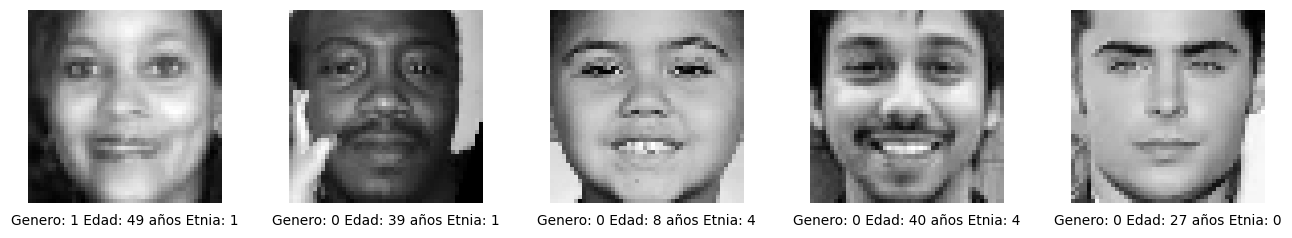

In [4]:
print(f"Total de imágenes: {len(df)}")

X = np.array([np.array(x.split(), dtype='float32').reshape(48, 48, 1) for x in df['pixels']])
X = X / 255.0

y_gender = df['gender'].values
y_age = df['age'].values
y_ethnicity = df['ethnicity'].values

# Visualización de muestra
plt.figure(figsize=(12, 4))
for i in range(5):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(X[i].reshape(48, 48), cmap='gray')
    plt.axis('off')
    ax.text(0.5, -0.05, f"Genero: {y_gender[i]} Edad: {y_age[i]} años Etnia: {y_ethnicity[i]}", transform=ax.transAxes, ha='center', va='top', fontsize=9)
plt.tight_layout()
guardar_fig("muestras_dataset")
plt.show()


--- Estadísticas Descriptivas ---


,age,ethnicity,gender
count,23705.000000,23705.000000,23705.000000
mean,33.300907,1.269226,0.477283
std,19.885708,1.345638,0.499494
min,1.000000,0.000000,0.000000
25%,23.000000,0.000000,0.000000
50%,29.000000,1.000000,0.000000
75%,45.000000,2.000000,1.000000
max,116.000000,4.000000,1.000000


[figura guardada] figs/exp2_distribuciones_dataset.png


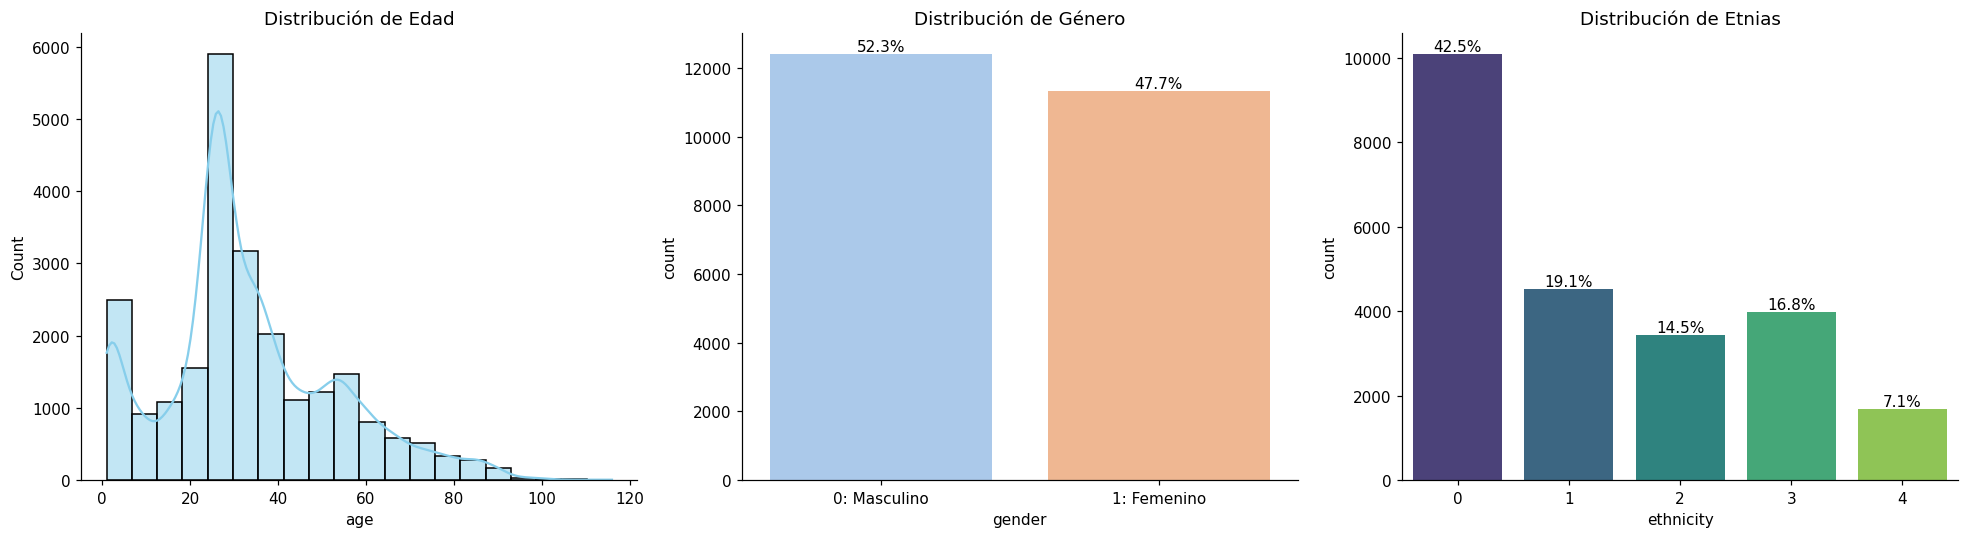

In [5]:
print("\n--- Estadísticas Descriptivas ---")
display(df.describe())

# Visualización de distribuciones con porcentajes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de Edad
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad')

# Función auxiliar para agregar porcentajes
def add_percentages(ax, total_count):
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total_count:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

# Distribución de Género
sns.countplot(x='gender', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Distribución de Género')
axes[1].set_xticklabels(['0: Masculino', '1: Femenino'])
add_percentages(axes[1], len(df))

# Distribución de Etnias
sns.countplot(x='ethnicity', data=df, ax=axes[2], palette='viridis')
axes[2].set_title('Distribución de Etnias')
add_percentages(axes[2], len(df))

plt.tight_layout()
guardar_fig("distribuciones_dataset")
plt.show()

Se puede denotar que los valores de age se concentan mas entre los 20 y 40, en genero estan bien balanceadas las clases y en la etnia vemos un claro desbalance, siendo la clase 0 mucho mayor y la 4 mucho menor que el resto de clases.

PARTICIONES (split estratificado por etnia, random_state=42)
Total :  23705 (100.00 %)
Train :  17126 (72.25 %)
Val   :   3023 (12.75 %)
Test  :   3556 (15.00 %)

--- Distribución de ETNIA por partición (%) ---


,Partición,N,Blanca(0),Negra(1),Asiática(2),India(3),Otra(4)
0,Total,23705,42.51 %,19.09 %,14.49 %,16.77 %,7.14 %
1,Train,17126,42.51 %,19.09 %,14.49 %,16.77 %,7.14 %
2,Val,3023,42.51 %,19.09 %,14.49 %,16.77 %,7.15 %
3,Test,3556,42.52 %,19.09 %,14.48 %,16.76 %,7.14 %



--- Distribución de GÉNERO por partición (%) ---


,Partición,N,Hombre(0),Mujer(1)
0,Total,23705,52.27 %,47.73 %
1,Train,17126,52.35 %,47.65 %
2,Val,3023,51.94 %,48.06 %
3,Test,3556,52.17 %,47.83 %



--- Distribución de EDAD por partición (años reales) ---


,Partición,N,media,std,min,p25,mediana,p75,max
0,Total,23705,33.30,19.89,1,23,29,45,116
1,Train,17126,33.28,19.81,1,23,29,45,116
2,Val,3023,33.57,20.06,1,23,30,45,116
3,Test,3556,33.18,20.11,1,23,29,45,111


[figura guardada] figs/exp2_dist_etnia_particiones.png


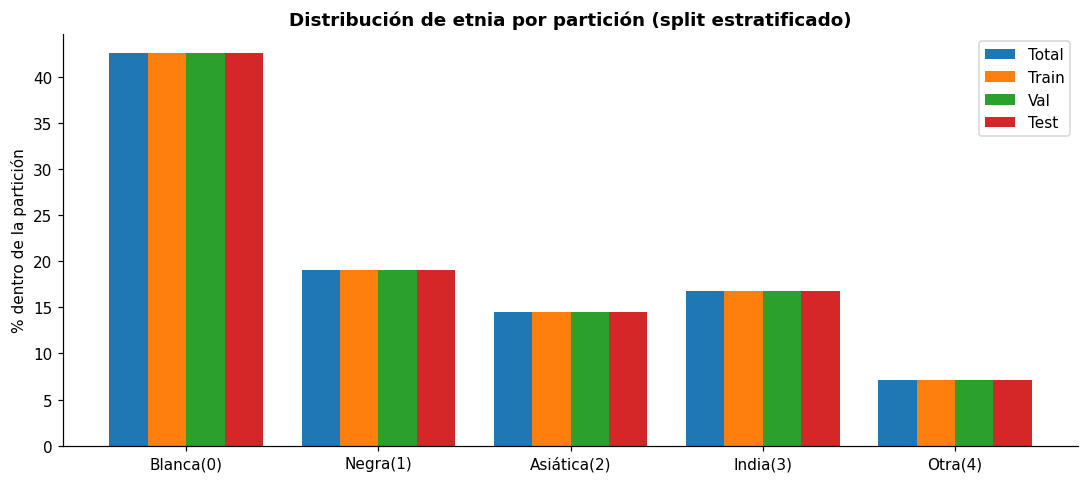


Set de Entrenamiento: 17126 imágenes


In [6]:
# =============================================================================
# SPLIT ESTRATIFICADO POR ETNIA (dos niveles) + distribuciones
# =============================================================================
scaler_age = MinMaxScaler()
y_age_scaled = scaler_age.fit_transform(y_age.reshape(-1, 1)).flatten()
y_ethnicity_ohe = keras.utils.to_categorical(y_ethnicity)  # shape (N, 5)

# NOTA: arrastramos también y_ethnicity (entero) para poder estratificar el 2do nivel.
(X_temp, X_test,
 y_gender_temp, y_gender_test,
 y_age_temp, y_age_test,
 y_eth_temp, y_eth_test,
 y_ethint_temp, y_ethint_test) = train_test_split(
    X, y_gender, y_age_scaled, y_ethnicity_ohe, y_ethnicity,
    test_size=0.15,
    random_state=SEED,
    stratify=y_ethnicity          # <-- NIVEL 1 ESTRATIFICADO
)

(X_train, X_val,
 y_gender_train, y_gender_val,
 y_age_train, y_age_val,
 y_eth_train, y_eth_val,
 y_ethint_train, y_ethint_val) = train_test_split(
    X_temp, y_gender_temp, y_age_temp, y_eth_temp, y_ethint_temp,
    test_size=0.15,
    random_state=SEED,
    stratify=y_ethint_temp        # <-- NIVEL 2 ESTRATIFICADO
)

# ── N exacto de cada partición ───────────────────────────────────────────────
n_total = len(X)
n_train, n_val, n_test = len(X_train), len(X_val), len(X_test)
print("=" * 70)
print("PARTICIONES (split estratificado por etnia, random_state=%d)" % SEED)
print("=" * 70)
print(f"Total : {n_total:6d} (100.00 %)")
print(f"Train : {n_train:6d} ({n_train/n_total*100:5.2f} %)")
print(f"Val   : {n_val:6d} ({n_val/n_total*100:5.2f} %)")
print(f"Test  : {n_test:6d} ({n_test/n_total*100:5.2f} %)")
assert n_train + n_val + n_test == n_total, "Las particiones no suman el total"

registrar("n_total",  n_total)
registrar("n_train",  n_train)
registrar("n_val",    n_val)
registrar("n_test",   n_test)
registrar("split_estratificado", True)
registrar("split_test_size",  0.15)
registrar("split_val_size_sobre_temp", 0.15)

# ── Distribución de las TRES variables por partición ─────────────────────────
nombres_etnias_cortos = ['Blanca(0)', 'Negra(1)', 'Asiática(2)', 'India(3)', 'Otra(4)']

particiones = {
    "Total": (y_gender,       y_age,            y_ethnicity),
    "Train": (y_gender_train, None,             y_ethint_train),
    "Val":   (y_gender_val,   None,             y_ethint_val),
    "Test":  (y_gender_test,  None,             y_ethint_test),
}
# Edad real (des-escalada) por partición
edades_part = {
    "Total": y_age.astype(float),
    "Train": scaler_age.inverse_transform(y_age_train.reshape(-1, 1)).flatten(),
    "Val":   scaler_age.inverse_transform(y_age_val.reshape(-1, 1)).flatten(),
    "Test":  scaler_age.inverse_transform(y_age_test.reshape(-1, 1)).flatten(),
}

# --- 1) ETNIA (% por clase) ---
filas_eth = []
for nombre, (_, _, eth) in particiones.items():
    conteo = np.bincount(np.asarray(eth).astype(int), minlength=5)
    fila = {"Partición": nombre, "N": int(conteo.sum())}
    for k in range(5):
        fila[nombres_etnias_cortos[k]] = f"{conteo[k]/conteo.sum()*100:.2f} %"
    filas_eth.append(fila)
df_dist_etnia = pd.DataFrame(filas_eth)
print("\n--- Distribución de ETNIA por partición (%) ---")
display(df_dist_etnia)

# --- 2) GÉNERO (% por clase) ---
filas_gen = []
for nombre, (gen, _, _) in particiones.items():
    conteo = np.bincount(np.asarray(gen).astype(int), minlength=2)
    filas_gen.append({
        "Partición": nombre, "N": int(conteo.sum()),
        "Hombre(0)": f"{conteo[0]/conteo.sum()*100:.2f} %",
        "Mujer(1)":  f"{conteo[1]/conteo.sum()*100:.2f} %",
    })
df_dist_genero = pd.DataFrame(filas_gen)
print("\n--- Distribución de GÉNERO por partición (%) ---")
display(df_dist_genero)

# --- 3) EDAD (estadísticos, en años reales) ---
filas_edad = []
for nombre, edades in edades_part.items():
    filas_edad.append({
        "Partición": nombre, "N": len(edades),
        "media": f"{edades.mean():.2f}", "std": f"{edades.std():.2f}",
        "min": f"{edades.min():.0f}", "p25": f"{np.percentile(edades,25):.0f}",
        "mediana": f"{np.median(edades):.0f}", "p75": f"{np.percentile(edades,75):.0f}",
        "max": f"{edades.max():.0f}",
    })
df_dist_edad = pd.DataFrame(filas_edad)
print("\n--- Distribución de EDAD por partición (años reales) ---")
display(df_dist_edad)

# ── Métricas al JSON: proporción por clase de etnia en cada partición ────────
for nombre, (_, _, eth) in particiones.items():
    conteo = np.bincount(np.asarray(eth).astype(int), minlength=5)
    for k in range(5):
        registrar(f"prop_etnia_{k}_{nombre.lower()}", conteo[k] / conteo.sum())
for nombre, (gen, _, _) in particiones.items():
    registrar(f"prop_genero_mujer_{nombre.lower()}", float(np.mean(gen)))
for nombre, edades in edades_part.items():
    registrar(f"edad_media_{nombre.lower()}", float(edades.mean()))

# ── Figura: distribución de etnia por partición ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
anchos = np.arange(5)
for i, (nombre, (_, _, eth)) in enumerate(particiones.items()):
    conteo = np.bincount(np.asarray(eth).astype(int), minlength=5)
    ax.bar(anchos + i * 0.2 - 0.3, conteo / conteo.sum() * 100, width=0.2, label=nombre)
ax.set_xticks(anchos); ax.set_xticklabels(nombres_etnias_cortos)
ax.set_ylabel("% dentro de la partición")
ax.set_title("Distribución de etnia por partición (split estratificado)", fontweight="bold")
ax.legend()
plt.tight_layout()
guardar_fig("dist_etnia_particiones")
plt.show()

print(f"\nSet de Entrenamiento: {len(X_train)} imágenes")

Aplicamos escalado a la variable edad para estabilizar el entrenamiento, aplicamos one hot encoding a etnia para evitar que se cree una falsa jerarquia entre las categorias, luego solucionaremos el problema del desbalance. En cuanto a genero no se toca nada, es una variable binaria bien balnceada, perfecta para entrenar.

In [7]:
# Creamos el DataFrame con todas las variables transformadas
tabla = pd.DataFrame({
    'Índice': [f'Img {i}' for i in range(5)],
    'Edad Original': y_age[:5],
    'Edad Escalada': [f'{val:.4f}' for val in y_age_scaled[:5]], # Formateado a 4 decimales
    'Género': y_gender[:5],
    'Etnia Original': y_ethnicity[:5],
    'Etnia OHE': [str(arr) for arr in y_ethnicity_ohe[:5]]
})

# Aplicamos los estilos CSS para formato de informe (fondo blanco)
tabla_informe = tabla.style.set_table_styles([
    # Estilo del encabezado (Gris claro, texto en negrita)
    {'selector': 'thead th',
     'props': [('background-color', '#f4f4f4'),
               ('color', 'black'),
               ('font-weight', 'bold'),
               ('border', '1px solid black'),
               ('text-align', 'center'),
               ('padding', '8px')]},
    # Estilo de las celdas (Fondo blanco rígido, texto centrado)
    {'selector': 'tbody td',
     'props': [('border', '1px solid #cccccc'),
               ('background-color', 'white'),
               ('color', 'black'),
               ('text-align', 'center'),
               ('padding', '8px')]},
    # Configuración general de la tabla
    {'selector': 'table',
     'props': [('border-collapse', 'collapse'),
               ('margin', '10px 0')]}
]).hide(axis='index') # Ocultamos el índice automático de Pandas

# Mostramos la tabla renderizada
tabla_informe

Índice,Edad Original,Edad Escalada,Género,Etnia Original,Etnia OHE
Img 0,49,0.4174,1,1,[0. 1. 0. 0. 0.]
Img 1,39,0.3304,0,1,[0. 1. 0. 0. 0.]
Img 2,8,0.0609,0,4,[0. 0. 0. 0. 1.]
Img 3,40,0.3391,0,4,[0. 0. 0. 0. 1.]
Img 4,27,0.2261,0,0,[1. 0. 0. 0. 0.]


In [8]:
# =============================================================================
# Dense vs CNN — presupuesto de parámetros IGUALADO + variante original
# =============================================================================
# Contexto: la versión original comparaba Dense(128) = 295.169 params contra
# CNN GAP = 96.833 params, SIN EarlyStopping. Era una comparación a presupuesto
# DESIGUAL (3,05x a favor del Dense) y sin criterio de parada común.
# Aquí se construyen TRES modelos y se declara explícitamente el presupuesto.

# ── Modelo A: Dense original (Dense 128) — se conserva para trazabilidad ─────
modelo_dense_edad = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='linear')   # linear para regresión
], name="Dense_Edad")
modelo_dense_edad.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ── Modelo B: CNN Equilibrada con GAP (Edad) ────────────────────────────────
modelo_conv_edad = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
], name="CNN_Edad_GAP")
modelo_conv_edad.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ── Modelo C: Dense ISO-PARÁMETROS (mismo orden de magnitud que la CNN) ─────
# Flatten -> 2304 features. Con u unidades ocultas: 2304*u + u + (u + 1) params.
# u = 42  ->  2304*42 + 42 + 43 = 96.853 params  (~ 96.833 de la CNN, +0,02 %)
UNIDADES_ISO = 42
modelo_dense_edad_iso = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),
    layers.Flatten(),
    layers.Dense(UNIDADES_ISO, activation='relu'),
    layers.Dense(1, activation='linear')
], name="Dense_Edad_ISO")
modelo_dense_edad_iso.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ── DECLARACIÓN EXPLÍCITA DEL PRESUPUESTO ───────────────────────────────────
p_dense     = modelo_dense_edad.count_params()
p_conv      = modelo_conv_edad.count_params()
p_dense_iso = modelo_dense_edad_iso.count_params()

df_presupuesto = pd.DataFrame({
    "Modelo":            ["Dense_Edad (original)", "CNN_Edad_GAP", "Dense_Edad_ISO (nuevo)"],
    "Parámetros":        [f"{p_dense:,}", f"{p_conv:,}", f"{p_dense_iso:,}"],
    "Ratio vs CNN":      [f"{p_dense/p_conv:.2f}x", "1.00x", f"{p_dense_iso/p_conv:.2f}x"],
    "Presupuesto":       ["DESIGUAL", "referencia", "IGUALADO (±1 %)"],
    "EarlyStopping":     ["SÍ (patience=8)", "SÍ (patience=8)", "SÍ (patience=8)"],
    "Épocas máx.":       [20, 20, 20],
})
print("=" * 78)
print("PRESUPUESTO DECLARADO — comparación Dense vs CNN (tarea: edad)")
print("=" * 78)
display(df_presupuesto)
print("\nDECLARACIÓN: la comparación Dense_Edad (original) vs CNN_Edad_GAP es a")
print("PRESUPUESTO DESIGUAL — el Dense tiene %.2fx más parámetros. La conclusión" % (p_dense/p_conv))
print("sobre superioridad arquitectónica se sostiene sobre Dense_Edad_ISO vs")
print("CNN_Edad_GAP, que sí están a presupuesto igualado (%s vs %s params)." %
      (f"{p_dense_iso:,}", f"{p_conv:,}"))
print("Ambos comparten AHORA el mismo criterio de parada (EarlyStopping val_loss,")
print("patience=8, restore_best_weights=True) y el mismo ReduceLROnPlateau.")

registrar("params_dense_edad_original", p_dense)
registrar("params_cnn_edad_gap",        p_conv)
registrar("params_dense_edad_iso",      p_dense_iso)
registrar("ratio_params_dense_vs_cnn",  p_dense / p_conv)
registrar("ratio_params_dense_iso_vs_cnn", p_dense_iso / p_conv)

PRESUPUESTO DECLARADO — comparación Dense vs CNN (tarea: edad)


,Modelo,Parámetros,Ratio vs CNN,Presupuesto,EarlyStopping,Épocas máx.
0,Dense_Edad (original),"295,169",3.05x,DESIGUAL,SÍ (patience=8),20
1,CNN_Edad_GAP,"96,833",1.00x,referencia,SÍ (patience=8),20
2,Dense_Edad_ISO (nuevo),"96,853",1.00x,IGUALADO (±1 %),SÍ (patience=8),20



DECLARACIÓN: la comparación Dense_Edad (original) vs CNN_Edad_GAP es a
PRESUPUESTO DESIGUAL — el Dense tiene 3.05x más parámetros. La conclusión
sobre superioridad arquitectónica se sostiene sobre Dense_Edad_ISO vs
CNN_Edad_GAP, que sí están a presupuesto igualado (96,853 vs 96,833 params).
Ambos comparten AHORA el mismo criterio de parada (EarlyStopping val_loss,
patience=8, restore_best_weights=True) y el mismo ReduceLROnPlateau.


1.0002

Entrenando modelo Dense (original, 128 unidades)
Epoch 1/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1656 - mae: 0.1879 - val_loss: 0.0305 - val_mae: 0.1313 - learning_rate: 0.0010
Epoch 2/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0235 - mae: 0.1186 - val_loss: 0.0410 - val_mae: 0.1606 - learning_rate: 0.0010
Epoch 3/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0223 - mae: 0.1155 - val_loss: 0.0269 - val_mae: 0.1242 - learning_rate: 0.0010
Epoch 4/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0207 - mae: 0.1109 - val_loss: 0.0258 - val_mae: 0.1213 - learning_rate: 0.0010
Epoch 5/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0190 - mae: 0.1062 - val_loss: 0.0232 - val_mae: 0.1146 - learning_rate: 0.0010
Epoch 6/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0184 - mae: 0.1037 - val_loss: 0.0314 - val_mae: 0.1344 - learning_rate: 0.0010
Epoch 7/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0176 - mae: 0.1007 - val_loss: 0.0219

,Modelo,Parámetros,Épocas corridas,Mejor val_loss,MAE test (años),Tiempo train (s),Presupuesto
0,Dense_Edad (original),"295,169",20,0.01368,9.90,36.4,DESIGUAL (3.05x)
1,CNN_Edad_GAP,"96,833",20,0.00707,7.26,68.0,referencia
2,Dense_Edad_ISO,"96,853",20,0.01341,9.99,35.9,IGUALADO



Comparación VÁLIDA a presupuesto igualado: Dense_ISO MAE=9.99 años
                                          CNN      MAE=7.26 años
Δ (Dense_ISO − CNN) = +2.72 años
[figura guardada] figs/exp2_dense_vs_cnn_edad.png


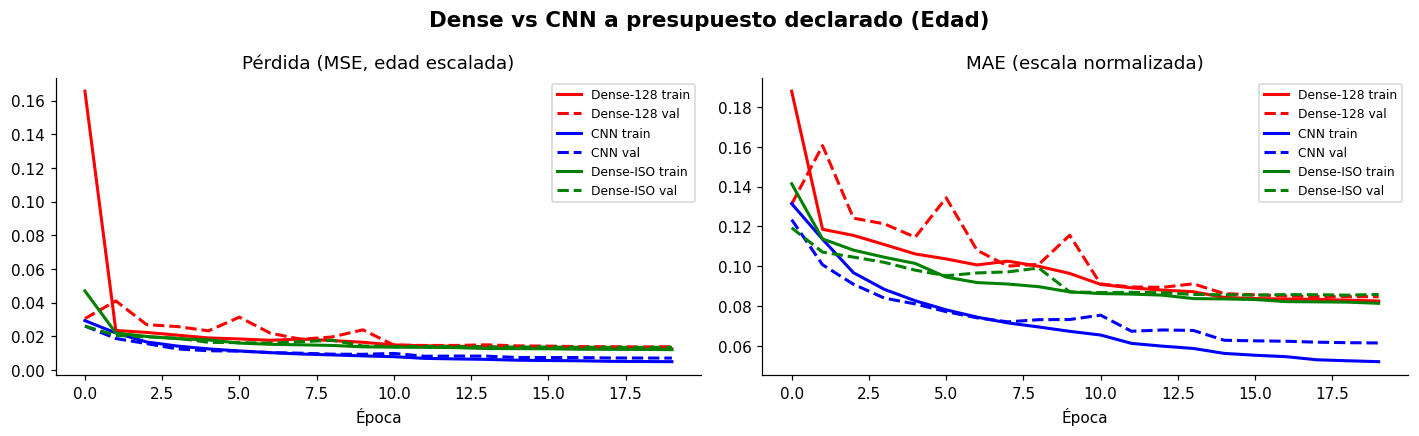

In [9]:
# =============================================================================
# Entrenamiento Dense / CNN / Dense-ISO con EL MISMO presupuesto
# =============================================================================
def nuevos_callbacks_edad():
    """Mismo criterio de parada para los TRES modelos (antes: es estaba comentado)."""
    return [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ]

EPOCAS_EDAD = 20
BATCH_EDAD  = 32

print("=" * 60); print("Entrenando modelo Dense (original, 128 unidades)"); print("=" * 60)
t0 = time.time()
h_dense_edad = modelo_dense_edad.fit(
    X_train, y_age_train, epochs=EPOCAS_EDAD, batch_size=BATCH_EDAD,
    validation_data=(X_val, y_age_val), callbacks=nuevos_callbacks_edad(), verbose=1)
tiempo_dense_edad = time.time() - t0

print("\n" + "=" * 60); print("Entrenando modelo CNN (GAP)"); print("=" * 60)
t0 = time.time()
h_conv_edad = modelo_conv_edad.fit(
    X_train, y_age_train, epochs=EPOCAS_EDAD, batch_size=BATCH_EDAD,
    validation_data=(X_val, y_age_val), callbacks=nuevos_callbacks_edad(), verbose=1)
tiempo_conv_edad = time.time() - t0

print("\n" + "=" * 60); print("Entrenando modelo Dense ISO (42 unidades, iso-parámetros)"); print("=" * 60)
t0 = time.time()
h_dense_edad_iso = modelo_dense_edad_iso.fit(
    X_train, y_age_train, epochs=EPOCAS_EDAD, batch_size=BATCH_EDAD,
    validation_data=(X_val, y_age_val), callbacks=nuevos_callbacks_edad(), verbose=1)
tiempo_dense_edad_iso = time.time() - t0

# ── Evaluación en TEST, en AÑOS reales (comparable entre los tres) ──────────
y_age_test_anios = scaler_age.inverse_transform(y_age_test.reshape(-1, 1)).flatten()

def mae_anios(modelo):
    p = scaler_age.inverse_transform(modelo.predict(X_test, verbose=0).reshape(-1, 1)).flatten()
    return float(mean_absolute_error(y_age_test_anios, p))

mae_dense     = mae_anios(modelo_dense_edad)
mae_conv      = mae_anios(modelo_conv_edad)
mae_dense_iso = mae_anios(modelo_dense_edad_iso)

df_dense_vs_cnn = pd.DataFrame({
    "Modelo":            ["Dense_Edad (original)", "CNN_Edad_GAP", "Dense_Edad_ISO"],
    "Parámetros":        [f"{p_dense:,}", f"{p_conv:,}", f"{p_dense_iso:,}"],
    "Épocas corridas":   [len(h_dense_edad.history['loss']),
                          len(h_conv_edad.history['loss']),
                          len(h_dense_edad_iso.history['loss'])],
    "Mejor val_loss":    [f"{min(h_dense_edad.history['val_loss']):.5f}",
                          f"{min(h_conv_edad.history['val_loss']):.5f}",
                          f"{min(h_dense_edad_iso.history['val_loss']):.5f}"],
    "MAE test (años)":   [f"{mae_dense:.2f}", f"{mae_conv:.2f}", f"{mae_dense_iso:.2f}"],
    "Tiempo train (s)":  [f"{tiempo_dense_edad:.1f}", f"{tiempo_conv_edad:.1f}",
                          f"{tiempo_dense_edad_iso:.1f}"],
    "Presupuesto":       ["DESIGUAL (3.05x)", "referencia", "IGUALADO"],
})
print("\n" + "=" * 78)
print("RESULTADO — Dense vs CNN (tarea edad). TODOS con EarlyStopping patience=8.")
print("=" * 78)
display(df_dense_vs_cnn)
print(f"\nComparación VÁLIDA a presupuesto igualado: Dense_ISO MAE={mae_dense_iso:.2f} años")
print(f"                                          CNN      MAE={mae_conv:.2f} años")
print(f"Δ (Dense_ISO − CNN) = {mae_dense_iso - mae_conv:+.2f} años")

for k, v in [("mae_test_dense_edad_original", mae_dense),
             ("mae_test_cnn_edad_gap", mae_conv),
             ("mae_test_dense_edad_iso", mae_dense_iso),
             ("delta_mae_dense_iso_menos_cnn", mae_dense_iso - mae_conv),
             ("tiempo_train_dense_edad_s", tiempo_dense_edad),
             ("tiempo_train_cnn_edad_s", tiempo_conv_edad),
             ("tiempo_train_dense_edad_iso_s", tiempo_dense_edad_iso),
             ("epocas_dense_edad", len(h_dense_edad.history['loss'])),
             ("epocas_cnn_edad", len(h_conv_edad.history['loss'])),
             ("epocas_dense_edad_iso", len(h_dense_edad_iso.history['loss'])),
             ("best_val_loss_dense_edad", min(h_dense_edad.history['val_loss'])),
             ("best_val_loss_cnn_edad", min(h_conv_edad.history['val_loss'])),
             ("best_val_loss_dense_edad_iso", min(h_dense_edad_iso.history['val_loss']))]:
    registrar(k, v)

# ── Gráfico comparativo (3 curvas) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(h_dense_edad.history['loss'],         'r-',  lw=2, label='Dense-128 train')
axes[0].plot(h_dense_edad.history['val_loss'],     'r--', lw=2, label='Dense-128 val')
axes[0].plot(h_conv_edad.history['loss'],          'b-',  lw=2, label='CNN train')
axes[0].plot(h_conv_edad.history['val_loss'],      'b--', lw=2, label='CNN val')
axes[0].plot(h_dense_edad_iso.history['loss'],     'g-',  lw=2, label='Dense-ISO train')
axes[0].plot(h_dense_edad_iso.history['val_loss'], 'g--', lw=2, label='Dense-ISO val')
axes[0].set_title('Pérdida (MSE, edad escalada)'); axes[0].set_xlabel('Época'); axes[0].legend(fontsize=8)

axes[1].plot(h_dense_edad.history['mae'],         'r-',  lw=2, label='Dense-128 train')
axes[1].plot(h_dense_edad.history['val_mae'],     'r--', lw=2, label='Dense-128 val')
axes[1].plot(h_conv_edad.history['mae'],          'b-',  lw=2, label='CNN train')
axes[1].plot(h_conv_edad.history['val_mae'],      'b--', lw=2, label='CNN val')
axes[1].plot(h_dense_edad_iso.history['mae'],     'g-',  lw=2, label='Dense-ISO train')
axes[1].plot(h_dense_edad_iso.history['val_mae'], 'g--', lw=2, label='Dense-ISO val')
axes[1].set_title('MAE (escala normalizada)'); axes[1].set_xlabel('Época'); axes[1].legend(fontsize=8)

plt.suptitle("Dense vs CNN a presupuesto declarado (Edad)", fontsize=14, fontweight='bold')
plt.tight_layout()
guardar_fig("dense_vs_cnn_edad")
plt.show()

In [10]:
# =============================================================================
# BACKBONE COMÚN REUTILIZABLE (una sola definición para todo el nb)
# =============================================================================
# Antes: el backbone estaba escrito DOS VECES (inline en la celda del multi-task
# y de nuevo en build_backbone() de la sección de modelos independientes).
# Ahora hay una única fuente de verdad. `augmentar=True` habilita el aumento de datos.

def build_backbone(name_prefix, augmentar=False):
    """
    Backbone compartido: [aug opcional] + 3 bloques Conv + GAP + Dropout(0.4).
    Devuelve (input_tensor, features_tensor) para engancharle las cabezas.

    augmentar=False -> backbone sin capas de aumento.
    augmentar=True  -> antepone RandomFlip('horizontal') + RandomTranslation(0.1, 0.1).
                       Las capas de aumento SOLO actúan en training=True; en
                       inferencia son identidad y NO agregan parámetros entrenables.
    """
    inp = keras.Input(shape=(48, 48, 1), name=f"{name_prefix}_entrada")

    if augmentar:
        x = keras.layers.RandomFlip("horizontal", seed=SEED,
                                    name=f"{name_prefix}_aug_flip")(inp)
        x = keras.layers.RandomTranslation(0.1, 0.1, seed=SEED,
                                           name=f"{name_prefix}_aug_shift")(x)
    else:
        x = inp

    # Bloque 1  (ojo: la 1ra Conv NO lleva BatchNorm — se respeta el original)
    x = keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)          # 24x24
    # Bloque 2
    x = keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)          # 12x12
    # Bloque 3
    x = keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)          # 6x6
    # Cuello de botella
    x = keras.layers.GlobalAveragePooling2D()(x)      # vector de 128
    x = keras.layers.Dropout(0.4)(x)
    return inp, x


# ── Constructores de cabezas (una sola definición, reutilizadas) ────────────
# ACTIVACIÓN DE LA CABEZA DE EDAD — decisión declarada explícitamente:
ACTIVACION_EDAD = 'sigmoid'   # <-- el código REAL usa sigmoid, no linear

def cabeza_genero(x, nombre='salida_genero'):
    h = keras.layers.Dense(64, activation='relu')(x)
    return keras.layers.Dense(1, activation='sigmoid', name=nombre)(h)

def cabeza_edad(x, nombre='salida_edad'):
    h = keras.layers.Dense(64, activation='relu')(x)
    return keras.layers.Dense(1, activation=ACTIVACION_EDAD, name=nombre)(h)

def cabeza_etnia(x, nombre='salida_etnia'):
    h = keras.layers.Dense(64, activation='relu')(x)
    return keras.layers.Dense(5, activation='softmax', name=nombre)(h)


def construir_multitask(nombre="CNN_Audiencias_Completa", augmentar=False):
    """Modelo multi-task de 3 cabezas sobre el backbone común."""
    inp, feats = build_backbone("mt" if not augmentar else "mt_aug", augmentar=augmentar)
    return keras.Model(
        inputs=inp,
        outputs=[cabeza_genero(feats), cabeza_edad(feats), cabeza_etnia(feats)],
        name=nombre
    )

print("build_backbone() / cabeza_*() / construir_multitask() definidos.")
print(f"ACTIVACION_EDAD = '{ACTIVACION_EDAD}'")

build_backbone() / cabeza_*() / construir_multitask() definidos.
ACTIVACION_EDAD = 'sigmoid'


In [11]:
# =============================================================================
# Multi-task construido con el backbone COMÚN + auditoría de la
#            activación de la cabeza de edad
# =============================================================================
modelo_multitask = construir_multitask("CNN_Audiencias_Completa", augmentar=False)
modelo_multitask.summary()

# ── AUDITORÍA DE LA CABEZA DE EDAD (lo que el modelo REALMENTE tiene) ───────
capa_edad = modelo_multitask.get_layer('salida_edad')
act_real = keras.activations.serialize(capa_edad.activation)
if isinstance(act_real, dict):
    act_real = act_real.get('class_name', str(act_real))
act_real = str(act_real)

print("\n" + "=" * 78)
print("AUDITORÍA DE LA CABEZA DE EDAD")
print("=" * 78)
print(f"Capa de salida de edad     : '{capa_edad.name}'")
print(f"Unidades                   : {capa_edad.units}")
print(f"ACTIVACIÓN REAL EN EL CÓDIGO: {act_real}")
print(f"Pérdida asociada           : mse (ver celda de compilación)")
print("-" * 78)
print("Rango de la variable objetivo (y_age_scaled):")
print(f"  min = {y_age_scaled.min():.4f} | max = {y_age_scaled.max():.4f}")
print(f"  edad real correspondiente: [{scaler_age.data_min_[0]:.0f}, "
      f"{scaler_age.data_max_[0]:.0f}] años (MinMaxScaler ajustado sobre y_age)")
print("-" * 78)
if act_real == 'sigmoid':
    print("ACTIVACIÓN DE LA CABEZA DE EDAD:")
    print("  La cabeza de edad usa SIGMOID. La elección es CONSISTENTE porque el")
    print("  target fue normalizado con MinMaxScaler al rango [0, 1]: la sigmoid")
    print("  restringe la predicción exactamente a ese soporte, actuando como")
    print("  regularizador de rango (no puede predecir edades negativas ni > máx).")
    print("  COSTO: satura en los extremos -> gradiente ~0 para edades muy bajas o")
    print("  muy altas, lo que penaliza justamente las colas de la distribución.")
    print("  Toda métrica de edad se reporta en AÑOS tras scaler_age.inverse_transform().")
else:
    print(f"DECLARACIÓN: la activación es '{act_real}'. Verificar coherencia con el escalado.")
print("=" * 78)

registrar("activacion_cabeza_edad_real", act_real)
registrar("edad_target_escalada", "MinMaxScaler [0,1]")
registrar("edad_min_anios", float(scaler_age.data_min_[0]))
registrar("edad_max_anios", float(scaler_age.data_max_[0]))
registrar("params_multitask", modelo_multitask.count_params())

Model: "CNN_Audiencias_Completa"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mt_entrada          │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 48,    │        320 │ mt_entrada[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 48,    │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 24, 24,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 12, 12,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 12, 12,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        512 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 6, 6, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_5[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_genero       │ (None, 1)         │         65 │ dense_6[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_edad (Dense) │ (None, 1)         │         65 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 128,039 (500.15 KB)

 Trainable params: 127,591 (498.40 KB)

 Non-trainable params: 448 (1.75 KB)


AUDITORÍA DE LA CABEZA DE EDAD
Capa de salida de edad     : 'salida_edad'
Unidades                   : 1
ACTIVACIÓN REAL EN EL CÓDIGO: sigmoid
Pérdida asociada           : mse (ver celda de compilación)
------------------------------------------------------------------------------
Rango de la variable objetivo (y_age_scaled):
  min = 0.0000 | max = 1.0000
  edad real correspondiente: [1, 116] años (MinMaxScaler ajustado sobre y_age)
------------------------------------------------------------------------------
ACTIVACIÓN DE LA CABEZA DE EDAD:
  La cabeza de edad usa SIGMOID. La elección es CONSISTENTE porque el
  target fue normalizado con MinMaxScaler al rango [0, 1]: la sigmoid
  restringe la predicción exactamente a ese soporte, actuando como
  regularizador de rango (no puede predecir edades negativas ni > máx).
  COSTO: satura en los extremos -> gradiente ~0 para edades muy bajas o
  muy altas, lo que penaliza justamente las colas de la distribución.
  Toda métrica de edad se rep

128039

In [12]:
import numpy as np

# Pesos por clase para la cabeza de etnia.
# Peso = 100% / (Cantidad_de_Clases * Porcentaje_de_la_Clase)
diccionario_pesos_etnia = {
    0: 0.47,
    1: 1.05,
    2: 1.38,
    3: 1.19,
    4: 1.72
}
PESOS_ETNIA = np.array([diccionario_pesos_etnia[i] for i in range(5)], dtype="float32")

def cce_ponderada_etnia(y_true, y_pred):
    """Cross-entropy categorica ponderada por clase.

    Cada muestra pesa segun su clase real de etnia, de modo que la ponderacion
    afecta unicamente a esta cabeza. Se implementa dentro de la perdida porque
    `sample_weight` por salida no es soportado en modelos multi-salida de Keras 3.
    """
    pesos = tf.reduce_sum(y_true * tf.constant(PESOS_ETNIA), axis=-1)
    return pesos * keras.losses.categorical_crossentropy(y_true, y_pred)

# Compilando el modelo con funciones de pérdida específicas para cada cabeza
modelo_multitask.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'salida_genero': 'binary_crossentropy',    # Para clasificación de 0 o 1
        'salida_edad': 'mse',                      # Error cuadrático medio para regresión continua
        'salida_etnia': cce_ponderada_etnia         # Multiclase One-Hot, ponderada por clase
    },
    loss_weights={
        'salida_genero': 1.0,
        'salida_edad': 25.0,  # Compensa la menor escala del MSE frente a las entropias
        'salida_etnia': 0.5   # Reduce el peso relativo de la tarea de etnia
    },
    metrics={
        'salida_genero': 'accuracy',
        'salida_edad': 'mae',                      # Error Absoluto Medio (fácil de interpretar)
        'salida_etnia': 'accuracy'
    }
)

callbacks =[
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("Iniciando el entrenamiento...")

t0_mt = time.time()
historial = modelo_multitask.fit(
    x=X_train,

    # Entregamos las etiquetas de entrenamiento conectadas a sus salidas
    y=
        {
            'salida_genero': y_gender_train,
            'salida_edad': y_age_train,
            'salida_etnia': y_eth_train
        },

    # Entregamos los datos de validación con su respectivo diccionario
    validation_data=(
        X_val,
        {
            'salida_genero': y_gender_val,
            'salida_edad': y_age_val,
            'salida_etnia': y_eth_val
        }
    ),

    epochs=40,              # Límite máximo de vueltas al dataset
    batch_size=32,          # Procesa las imágenes de a 32 por vez
    callbacks=callbacks,
    verbose=1
)

tiempo_train_mt = time.time() - t0_mt
print(f"Tiempo de entrenamiento multi-task: {tiempo_train_mt:.1f} s")

Iniciando el entrenamiento...
Epoch 1/40
536/536 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 1.7717 - salida_edad_loss: 0.0210 - salida_edad_mae: 0.1099 - salida_etnia_accuracy: 0.4062 - salida_etnia_loss: 1.3392 - salida_genero_accuracy: 0.6933 - salida_genero_loss: 0.5768 - val_loss: 2.5916 - val_salida_edad_loss: 0.0473 - val_salida_edad_mae: 0.1647 - val_salida_etnia_accuracy: 0.2855 - val_salida_etnia_loss: 1.4237 - val_salida_genero_accuracy: 0.5653 - val_salida_genero_loss: 0.7032 - learning_rate: 0.0010
Epoch 2/40
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.2472 - salida_edad_loss: 0.0124 - salida_edad_mae: 0.0842 - salida_etnia_accuracy: 0.5777 - salida_etnia_loss: 1.0635 - salida_genero_accuracy: 0.8178 - salida_genero_loss: 0.4042 - val_loss: 1.3137 - val_salida_edad_loss: 0.0172 - val_salida_edad_mae: 0.1062 - val_salida_etnia_accuracy: 0.5471 - val_salida_etnia_loss: 1.0352 - val_salida_genero_accuracy: 0.8455 - val_salida_genero_loss: 0.3637 - learning_rate: 0.0010


--- REPORTE DE GÉNERO (multi-task) ---
              precision    recall  f1-score   support

      Hombre      0.862     0.942     0.900      1855
       Mujer      0.930     0.835     0.880      1701

    accuracy                          0.891      3556
   macro avg      0.896     0.889     0.890      3556
weighted avg      0.894     0.891     0.891      3556

--- REPORTE DE ETNIA (multi-task) ---
              precision    recall  f1-score   support

  Blanca (0)      0.893     0.731     0.804      1512
   Negra (1)      0.801     0.875     0.836       679
Asiática (2)      0.774     0.880     0.824       515
   India (3)      0.623     0.790     0.697       596
    Otra (4)      0.336     0.311     0.323       254

    accuracy                          0.760      3556
   macro avg      0.685     0.717     0.697      3556
weighted avg      0.773     0.760     0.760      3556

--- REPORTE DE EDAD (regresión, multi-task) ---
MAE : 6.50 años   |   RMSE: 9.07 años
[figura guardada] fig

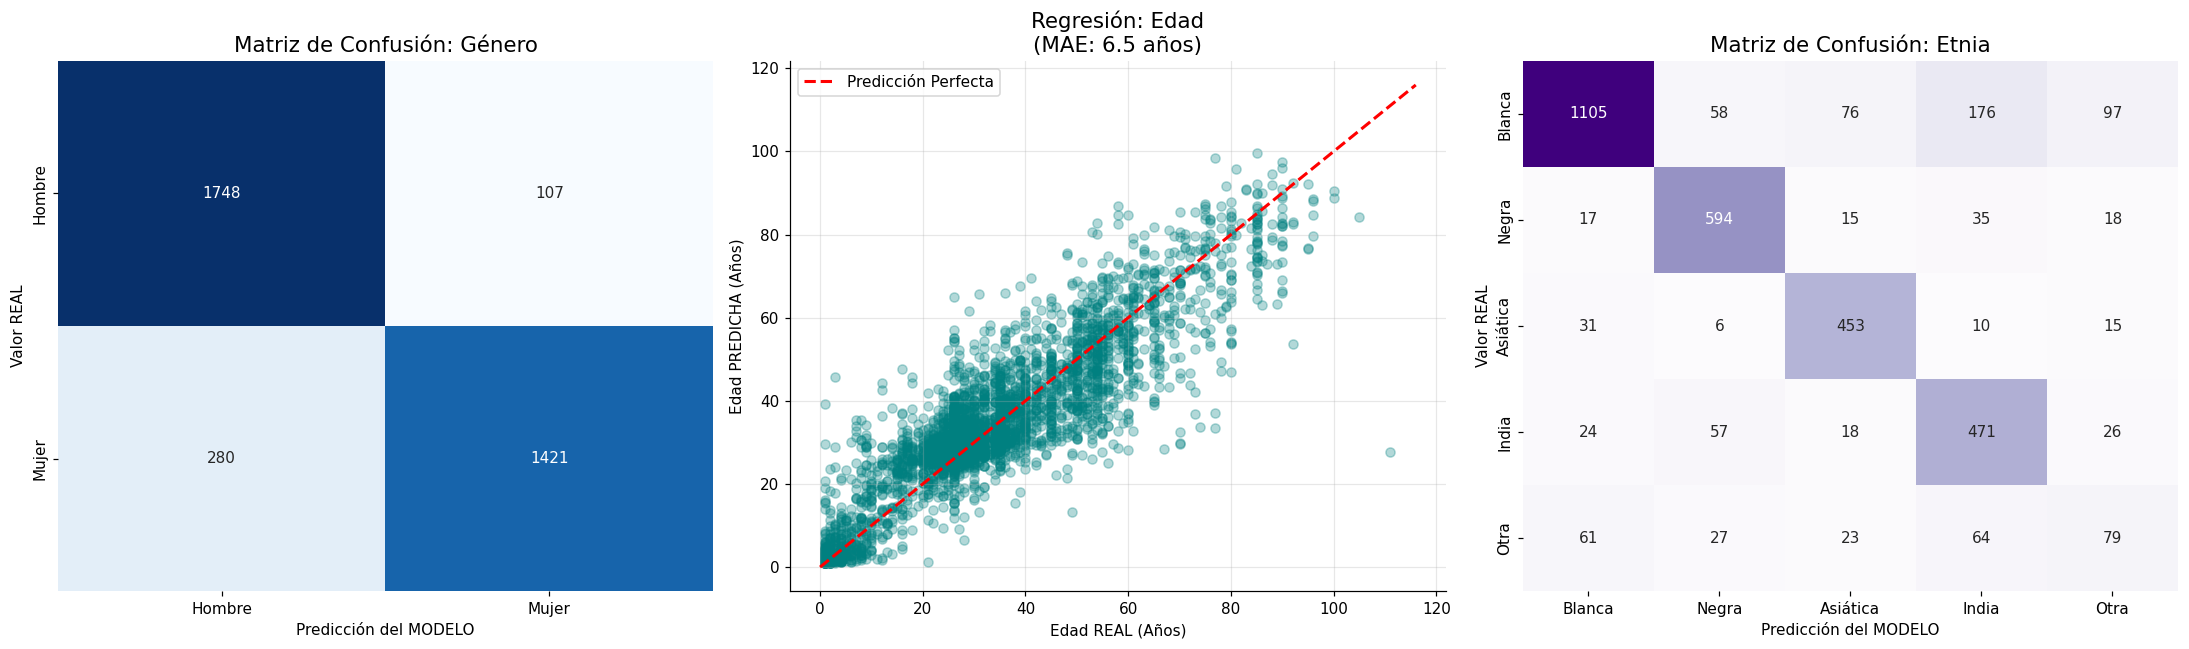

In [13]:
# =============================================================================
# Evaluación del multi-task en TEST (con registro de métricas por clase)
# =============================================================================
pred_gender_probs, pred_age_scaled, pred_eth_probs = modelo_multitask.predict(X_test, verbose=0)

pred_gender_clases = (pred_gender_probs > 0.5).astype(int).flatten()
pred_age_real   = scaler_age.inverse_transform(pred_age_scaled).flatten()
y_age_test_real = scaler_age.inverse_transform(y_age_test.reshape(-1, 1)).flatten()
pred_eth_clases = np.argmax(pred_eth_probs, axis=1)
y_eth_test_real = np.argmax(y_eth_test, axis=1)

nombres_etnias = ['Blanca (0)', 'Negra (1)', 'Asiática (2)', 'India (3)', 'Otra (4)']

print("=" * 55)
print("--- REPORTE DE GÉNERO (multi-task) ---")
print(classification_report(y_gender_test, pred_gender_clases,
                            target_names=['Hombre', 'Mujer'], digits=3))
print("=" * 55)
print("--- REPORTE DE ETNIA (multi-task) ---")
print(classification_report(y_eth_test_real, pred_eth_clases,
                            target_names=nombres_etnias, digits=3))
print("=" * 55)
mae_edad = mean_absolute_error(y_age_test_real, pred_age_real)
rmse_edad = float(np.sqrt(mean_squared_error(y_age_test_real, pred_age_real)))
print("--- REPORTE DE EDAD (regresión, multi-task) ---")
print(f"MAE : {mae_edad:.2f} años   |   RMSE: {rmse_edad:.2f} años")
print("=" * 55)

# ── Registro de métricas (multi-task) ───────────────────────────────────────
rep_eth_mt = classification_report(y_eth_test_real, pred_eth_clases,
                                   target_names=nombres_etnias, output_dict=True,
                                   zero_division=0)
registrar("mt_acc_genero", accuracy_score(y_gender_test, pred_gender_clases))
registrar("mt_f1_genero",  f1_score(y_gender_test, pred_gender_clases))
registrar("mt_mae_edad_anios", mae_edad)
registrar("mt_rmse_edad_anios", rmse_edad)
registrar("mt_acc_etnia", accuracy_score(y_eth_test_real, pred_eth_clases))
registrar("mt_macro_f1_etnia", rep_eth_mt["macro avg"]["f1-score"])
registrar("mt_weighted_f1_etnia", rep_eth_mt["weighted avg"]["f1-score"])
for k, nom in enumerate(nombres_etnias):
    registrar(f"mt_etnia_clase{k}_precision", rep_eth_mt[nom]["precision"])
    registrar(f"mt_etnia_clase{k}_recall",    rep_eth_mt[nom]["recall"])
    registrar(f"mt_etnia_clase{k}_f1",        rep_eth_mt[nom]["f1-score"])
    registrar(f"mt_etnia_clase{k}_support",   int(rep_eth_mt[nom]["support"]))

# ── DIAGNÓSTICO VISUAL ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cm_gender = confusion_matrix(y_gender_test, pred_gender_clases)
sns.heatmap(cm_gender, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Hombre', 'Mujer'], yticklabels=['Hombre', 'Mujer'], cbar=False)
axes[0].set_title('Matriz de Confusión: Género', fontsize=14)
axes[0].set_ylabel('Valor REAL'); axes[0].set_xlabel('Predicción del MODELO')

axes[1].scatter(y_age_test_real, pred_age_real, alpha=0.3, color='teal')
axes[1].plot([0, 116], [0, 116], color='red', linestyle='--', linewidth=2,
             label='Predicción Perfecta')
axes[1].set_title(f'Regresión: Edad\n(MAE: {mae_edad:.1f} años)', fontsize=14)
axes[1].set_xlabel("Edad REAL (Años)"); axes[1].set_ylabel("Edad PREDICHA (Años)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

cm_eth = confusion_matrix(y_eth_test_real, pred_eth_clases)
sns.heatmap(cm_eth, annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=['Blanca', 'Negra', 'Asiática', 'India', 'Otra'],
            yticklabels=['Blanca', 'Negra', 'Asiática', 'India', 'Otra'], cbar=False)
axes[2].set_title('Matriz de Confusión: Etnia', fontsize=14)
axes[2].set_ylabel('Valor REAL'); axes[2].set_xlabel('Predicción del MODELO')

plt.tight_layout()
guardar_fig("matrices_confusion_multitask")
plt.show()

[figura guardada] figs/exp2_curvas_aprendizaje_multitask.png


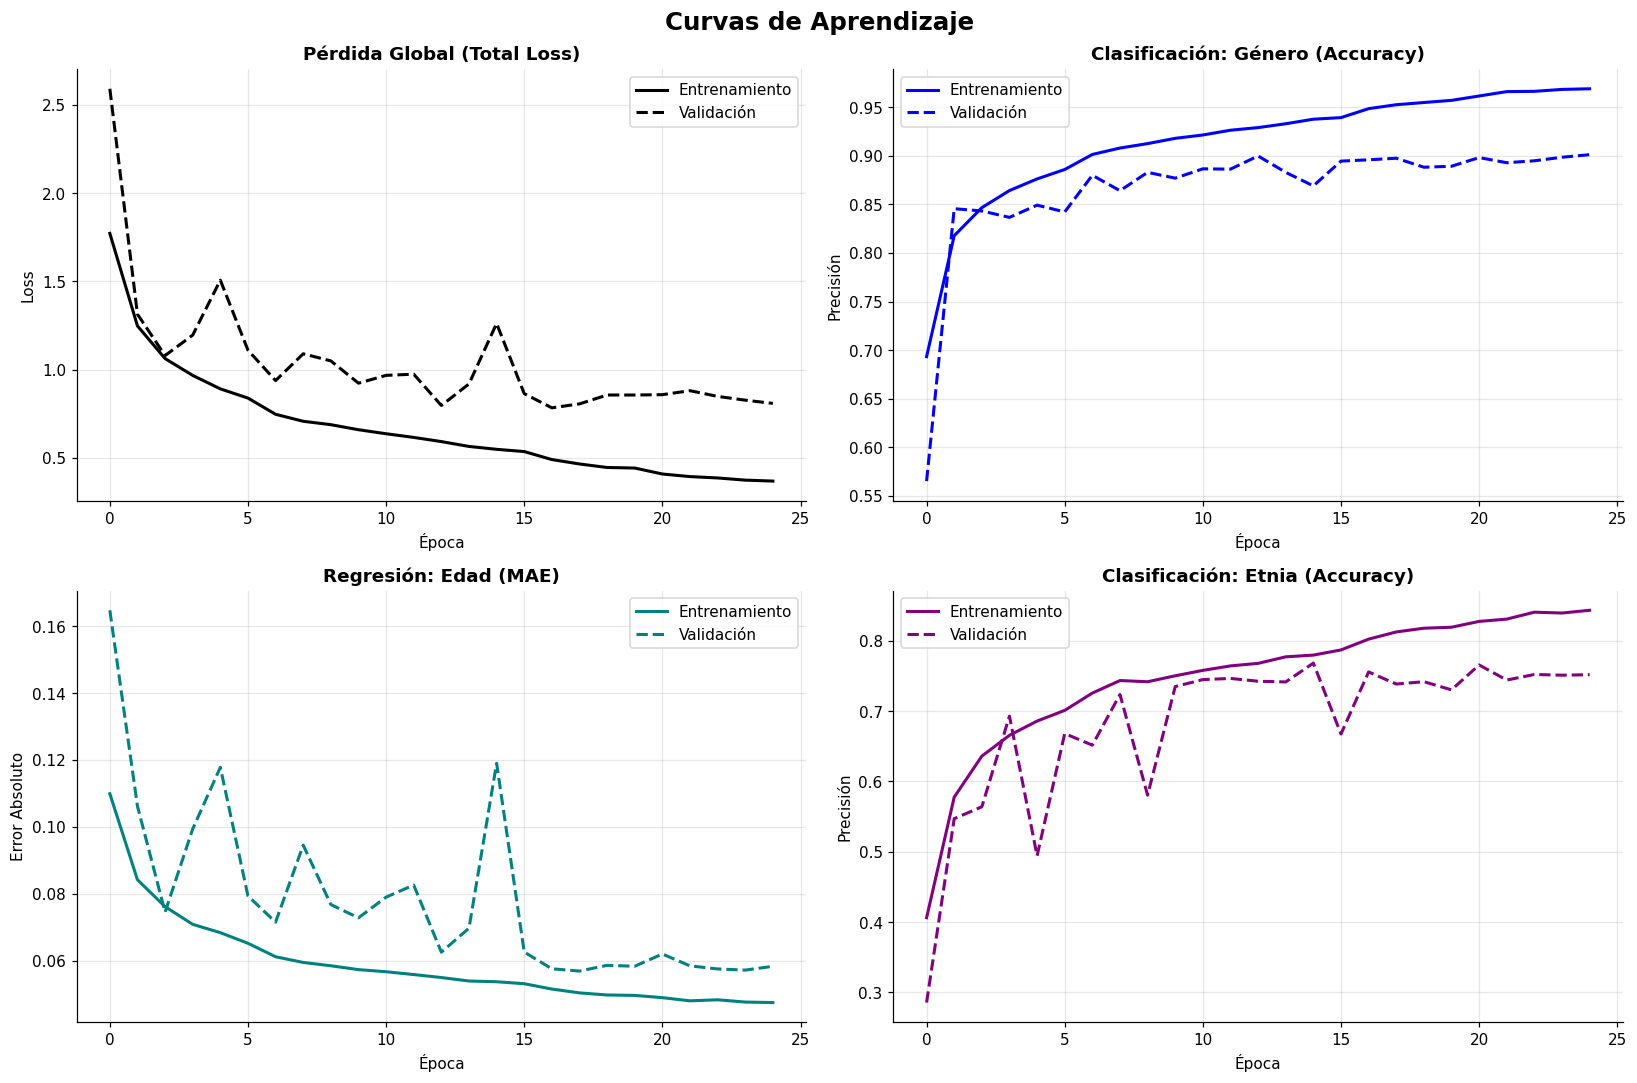

In [14]:
# Extraemos el diccionario de métricas del entrenamiento
metricas = historial.history

# Creamos un lienzo de 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Pérdida Global (Total Loss)
axes[0, 0].plot(metricas['loss'], label='Entrenamiento', color='black', lw=2)
axes[0, 0].plot(metricas['val_loss'], label='Validación', color='black', linestyle='--', lw=2)
axes[0, 0].set_title('Pérdida Global (Total Loss)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Precisión de Género
axes[0, 1].plot(metricas['salida_genero_accuracy'], label='Entrenamiento', color='blue', lw=2)
axes[0, 1].plot(metricas['val_salida_genero_accuracy'], label='Validación', color='blue', linestyle='--', lw=2)
axes[0, 1].set_title('Clasificación: Género (Accuracy)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Precisión')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Error Absoluto de Edad (MAE)
axes[1, 0].plot(metricas['salida_edad_mae'], label='Entrenamiento', color='teal', lw=2)
axes[1, 0].plot(metricas['val_salida_edad_mae'], label='Validación', color='teal', linestyle='--', lw=2)
axes[1, 0].set_title('Regresión: Edad (MAE)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Error Absoluto')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Precisión de Etnia
axes[1, 1].plot(metricas['salida_etnia_accuracy'], label='Entrenamiento', color='purple', lw=2)
axes[1, 1].plot(metricas['val_salida_etnia_accuracy'], label='Validación', color='purple', linestyle='--', lw=2)
axes[1, 1].set_title('Clasificación: Etnia (Accuracy)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Precisión')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Curvas de Aprendizaje", fontsize=16, fontweight='bold')
plt.tight_layout()
guardar_fig("curvas_aprendizaje_multitask")
plt.show()

In [15]:
# =============================================================================
# P-A / +(b) MEDICIÓN DE LATENCIA UNIFICADA — batch=1, 200 reps,
#                     calentamiento, media + P95 + FPS, hardware REAL etiquetado
#                     + medición forzada sobre CPU para argumentar embebido
# =============================================================================
# Reemplaza las DOS mediciones contradictorias del notebook original
# (36,64 ms con N=100 en esta celda, 32,73 ms con N=200 en la celda de timing).
# Protocolo único y declarado:
#   - batch = 1 (una imagen), tal como en el caso de uso de producción
#   - 20 pasadas de calentamiento descartadas (compilación XLA / carga de kernels)
#   - 200 pasadas cronometradas INDIVIDUALMENTE (permite calcular P95)
#   - sincronización forzada con np.asarray() sobre cada salida (la ejecución
#     en GPU es asíncrona: sin esto se cronometra el encolado, no el cómputo)
#   - se reporta media, mediana, P95, desvío y FPS = 1000 / media

N_REPS_LATENCIA   = 200
N_CALENTAMIENTO   = 20
BATCH_LATENCIA    = 1

muestra_latencia = X_test[:BATCH_LATENCIA]      # batch = 1

def _sincronizar(salida):
    """Fuerza la materialización del resultado (la GPU ejecuta de forma asíncrona)."""
    if isinstance(salida, (list, tuple)):
        for s in salida:
            np.asarray(s)
    else:
        np.asarray(salida)

def medir_latencia(modelo, muestra, n=N_REPS_LATENCIA, calentamiento=N_CALENTAMIENTO,
                   dispositivo=None):
    """
    Latencia por imagen en ms. `dispositivo` = None (el que elija TF),
    '/GPU:0' o '/CPU:0'. Devuelve dict con media, mediana, P95, std y FPS.
    Usa la llamada directa modelo(x, training=False): mide el forward puro,
    sin el overhead de armado de dataset que agrega .predict().
    """
    ctx = tf.device(dispositivo) if dispositivo else contextlib.nullcontext()
    with ctx:
        for _ in range(calentamiento):
            _sincronizar(modelo(muestra, training=False))
        tiempos = np.empty(n, dtype=np.float64)
        for i in range(n):
            t0 = time.perf_counter()
            _sincronizar(modelo(muestra, training=False))
            tiempos[i] = (time.perf_counter() - t0) * 1000.0
    return {
        "media_ms":   float(tiempos.mean()),
        "mediana_ms": float(np.percentile(tiempos, 50)),
        "p95_ms":     float(np.percentile(tiempos, 95)),
        "std_ms":     float(tiempos.std(ddof=1)),
        "min_ms":     float(tiempos.min()),
        "fps":        float(1000.0 / tiempos.mean()),
        "n":          int(n),
    }

def medir_latencia_predict(modelo, muestra, n=N_REPS_LATENCIA,
                           calentamiento=N_CALENTAMIENTO):
    """Variante con .predict(): incluye el overhead de la API de alto nivel."""
    for _ in range(calentamiento):
        modelo.predict(muestra, verbose=0)
    tiempos = np.empty(n, dtype=np.float64)
    for i in range(n):
        t0 = time.perf_counter()
        modelo.predict(muestra, verbose=0)
        tiempos[i] = (time.perf_counter() - t0) * 1000.0
    return {
        "media_ms": float(tiempos.mean()),
        "p95_ms":   float(np.percentile(tiempos, 95)),
        "fps":      float(1000.0 / tiempos.mean()),
        "n":        int(n),
    }

# ── 1. MEDICIÓN EN EL HARDWARE REALMENTE USADO ──────────────────────────────
print("=" * 78)
print(f"MEDICIÓN DE LATENCIA — hardware REAL: {ACELERADOR}")
print(f"batch={BATCH_LATENCIA} | calentamiento={N_CALENTAMIENTO} | repeticiones={N_REPS_LATENCIA}")
print("=" * 78)

lat_default = medir_latencia(modelo_multitask, muestra_latencia)
etiqueta_default = "GPU" if gpus else "CPU"
print(f"[{etiqueta_default}] forward directo  : media {lat_default['media_ms']:.2f} ms | "
      f"P95 {lat_default['p95_ms']:.2f} ms | {lat_default['fps']:.1f} FPS")

lat_predict = medir_latencia_predict(modelo_multitask, muestra_latencia)
print(f"[{etiqueta_default}] .predict()       : media {lat_predict['media_ms']:.2f} ms | "
      f"P95 {lat_predict['p95_ms']:.2f} ms | {lat_predict['fps']:.1f} FPS")
print("   (la diferencia entre ambas filas es overhead de Python/tf.data de .predict(),")
print("    no cómputo del modelo. El hardware real utilizado se declara arriba.)")

# ── 2. (b) MEDICIÓN FORZADA SOBRE CPU — base para hablar de embebido ────────
lat_cpu = None
cpu_forzada_ok = False
try:
    lat_cpu = medir_latencia(modelo_multitask, muestra_latencia, dispositivo='/CPU:0')
    cpu_forzada_ok = True
    print(f"\n[CPU:0 forzada] forward directo: media {lat_cpu['media_ms']:.2f} ms | "
          f"P95 {lat_cpu['p95_ms']:.2f} ms | {lat_cpu['fps']:.1f} FPS")
except Exception as e:
    print(f"\nNO se pudo forzar la ejecución en CPU: {type(e).__name__}: {e}")

# ── 3. DECLARACIÓN SOBRE HARDWARE EMBEBIDO ──────────────────────────────────
print("\n" + "=" * 78)
print("ALCANCE DE LA MEDICIÓN — hardware embebido")
print("=" * 78)
if cpu_forzada_ok:
    print(f"Se dispone de medición REAL sobre CPU ({lat_cpu['media_ms']:.2f} ms, "
          f"{lat_cpu['fps']:.1f} FPS), obtenida con tf.device('/CPU:0') sobre la")
    print("CPU del host de Colab (x86-64, varios núcleos). Toda afirmación sobre un")
    print("dispositivo embebido (ARM, Raspberry Pi, móvil) sigue siendo una")
    print("EXTRAPOLACIÓN: no se midió sobre ese hardware. El factor de degradación")
    print("respecto de esta CPU es un SUPUESTO NO VERIFICADO en este trabajo.")
    if gpus:
        print(f"Penalización medida GPU -> CPU: "
              f"{lat_cpu['media_ms']/lat_default['media_ms']:.2f}x más lento.")
else:
    print("SUPUESTO EXPLÍCITO: no fue posible aislar la ejecución en CPU en este")
    print("entorno, por lo que NO existe medición de latencia sobre CPU. Cualquier")
    print("afirmación sobre viabilidad en hardware embebido queda declarada como")
    print("EXTRAPOLACIÓN NO MEDIDA y no debe presentarse como resultado.")
print("=" * 78)

# ── 4. TABLA ÚNICA DE RENDIMIENTO ───────────────────────────────────────────
total_params = modelo_multitask.count_params()
peso_mb = total_params * 4 / (1024 ** 2)

filas = [
    ("Parámetros totales del modelo",           f"{total_params:,}"),
    ("Tamaño estimado en memoria (float32)",    f"{peso_mb:.2f} MB"),
    ("Hardware de medición (detectado)",        ACELERADOR),
    ("Protocolo",                               f"batch=1, {N_CALENTAMIENTO} warmup + {N_REPS_LATENCIA} reps"),
    (f"Latencia media [{etiqueta_default}]",    f"{lat_default['media_ms']:.2f} ms"),
    (f"Latencia P95 [{etiqueta_default}]",      f"{lat_default['p95_ms']:.2f} ms"),
    (f"Desvío estándar [{etiqueta_default}]",   f"{lat_default['std_ms']:.2f} ms"),
    (f"FPS [{etiqueta_default}]",               f"{lat_default['fps']:.1f} img/s"),
    (f"Latencia media .predict() [{etiqueta_default}]", f"{lat_predict['media_ms']:.2f} ms"),
    (f"FPS .predict() [{etiqueta_default}]",    f"{lat_predict['fps']:.1f} img/s"),
]
if cpu_forzada_ok:
    filas += [
        ("Latencia media [CPU forzada]", f"{lat_cpu['media_ms']:.2f} ms"),
        ("Latencia P95 [CPU forzada]",   f"{lat_cpu['p95_ms']:.2f} ms"),
        ("FPS [CPU forzada]",            f"{lat_cpu['fps']:.1f} img/s"),
    ]
else:
    filas += [("Latencia sobre CPU", "NO MEDIDA — extrapolación declarada como supuesto")]

df_rendimiento = pd.DataFrame(filas, columns=["Métrica de rendimiento", "Valor obtenido"])
display(df_rendimiento.style.hide(axis="index"))

# ── 5. Registro al JSON ─────────────────────────────────────────────────────
registrar("latencia_hardware", ACELERADOR)
registrar("latencia_batch", BATCH_LATENCIA)
registrar("latencia_reps", N_REPS_LATENCIA)
registrar("latencia_calentamiento", N_CALENTAMIENTO)
registrar("params_multitask", total_params)
registrar("peso_modelo_mb", peso_mb)
registrar(f"latencia_media_ms_{etiqueta_default.lower()}",   lat_default["media_ms"])
registrar(f"latencia_mediana_ms_{etiqueta_default.lower()}", lat_default["mediana_ms"])
registrar(f"latencia_p95_ms_{etiqueta_default.lower()}",     lat_default["p95_ms"])
registrar(f"latencia_std_ms_{etiqueta_default.lower()}",     lat_default["std_ms"])
registrar(f"fps_{etiqueta_default.lower()}",                 lat_default["fps"])
registrar("latencia_media_ms_predict", lat_predict["media_ms"])
registrar("latencia_p95_ms_predict",   lat_predict["p95_ms"])
registrar("fps_predict",               lat_predict["fps"])
registrar("cpu_forzada_medida", cpu_forzada_ok)
if cpu_forzada_ok:
    registrar("latencia_media_ms_cpu_forzada", lat_cpu["media_ms"])
    registrar("latencia_p95_ms_cpu_forzada",   lat_cpu["p95_ms"])
    registrar("fps_cpu_forzada",               lat_cpu["fps"])
    registrar("factor_penalizacion_cpu_vs_acelerador",
              lat_cpu["media_ms"] / lat_default["media_ms"])

MEDICIÓN DE LATENCIA — hardware REAL: GPU: Tesla T4
batch=1 | calentamiento=20 | repeticiones=200
[GPU] forward directo  : media 23.11 ms | P95 30.03 ms | 43.3 FPS
[GPU] .predict()       : media 73.28 ms | P95 102.73 ms | 13.6 FPS
   (la diferencia entre ambas filas es overhead de Python/tf.data de .predict(),
    no cómputo del modelo. El hardware real utilizado se declara arriba.)

[CPU:0 forzada] forward directo: media 27.47 ms | P95 33.30 ms | 36.4 FPS

ALCANCE DE LA MEDICIÓN — hardware embebido
Se dispone de medición REAL sobre CPU (27.47 ms, 36.4 FPS), obtenida con tf.device('/CPU:0') sobre la
CPU del host de Colab (x86-64, varios núcleos). Toda afirmación sobre un
dispositivo embebido (ARM, Raspberry Pi, móvil) sigue siendo una
EXTRAPOLACIÓN: no se midió sobre ese hardware. El factor de degradación
respecto de esta CPU es un SUPUESTO NO VERIFICADO en este trabajo.
Penalización medida GPU -> CPU: 1.19x más lento.


Métrica de rendimiento,Valor obtenido
Parámetros totales del modelo,"128,039"
Tamaño estimado en memoria (float32),0.49 MB
Hardware de medición (detectado),GPU: Tesla T4
Protocolo,"batch=1, 20 warmup + 200 reps"
Latencia media [GPU],23.11 ms
Latencia P95 [GPU],30.03 ms
Desvío estándar [GPU],4.42 ms
FPS [GPU],43.3 img/s
Latencia media .predict() [GPU],73.28 ms
FPS .predict() [GPU],13.6 img/s


--- Ejecutando Pipeline de Inferencia ---
Tiempo de inferencia: 126.06 ms
[figura guardada] figs/exp2_pipeline_inferencia.png


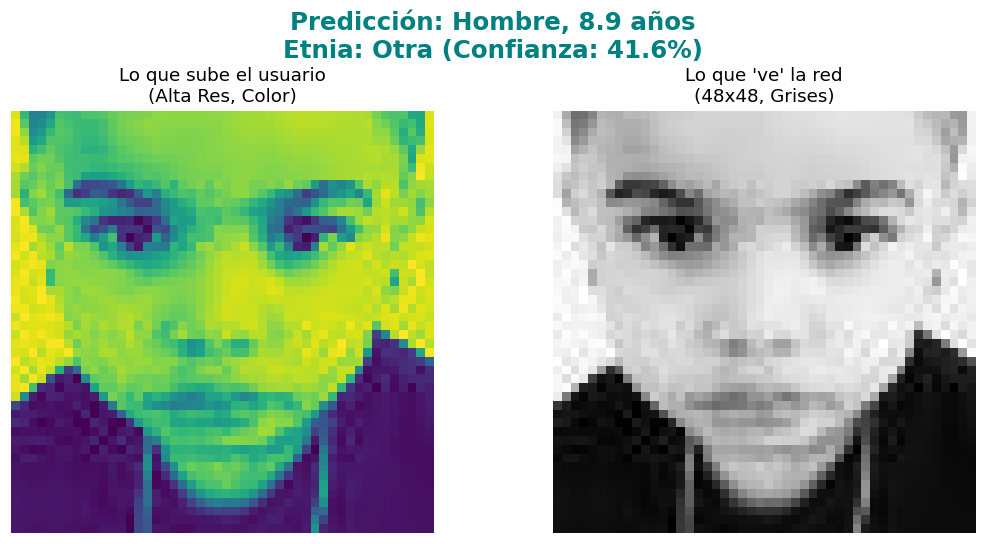

In [16]:
def procesar_e_inferir_imagen(ruta_imagen, modelo, escalador_edad):
    """
    Carga una imagen, la preprocesa, realiza la inferencia y compara visualmente
    la imagen original con el tensor que ingresa a la red.
    """
    try:
        # 1. Carga de la imagen original (Alta resolución, Color)
        img_original = Image.open(ruta_imagen)

        # 2. Preprocesamiento estricto (Debe coincidir con el entrenamiento)
        # Convertir a escala de grises ('L') y redimensionar a 48x48
        img_procesada = img_original.convert('L').resize((48, 48))

        # Convertir a array de numpy y normalizar al rango [0, 1]
        img_array = np.array(img_procesada, dtype='float32') / 255.0

        # Añadir dimensiones de batch y canal: El modelo espera (1, 48, 48, 1)
        input_tensor = img_array.reshape(1, 48, 48, 1)

        # 3. Inferencia (Forward Pass)
        # Atrapamos las tres salidas en el orden exacto de la arquitectura
        t_inicio = time.time()
        pred_genero_prob, pred_edad_escalada, pred_etnia_probs = modelo.predict(input_tensor, verbose=0)
        t_ms = (time.time() - t_inicio) * 1000
        print(f"Tiempo de inferencia: {t_ms:.2f} ms")

        # 4. Post-procesamiento (Traducción a reglas de negocio)

        # --- Género ---
        clase_genero = (pred_genero_prob[0][0] > 0.5).astype(int)
        genero_str = "Mujer" if clase_genero == 1 else "Hombre"

        # --- Edad ---
        edad_real = escalador_edad.inverse_transform(pred_edad_escalada).flatten()[0]

        # --- Etnia ---
        nombres_etnias = ['Blanca', 'Negra', 'Asiática', 'India', 'Otra']
        # Buscamos el índice con la probabilidad más alta
        clase_etnia = np.argmax(pred_etnia_probs, axis=1)[0]
        etnia_str = nombres_etnias[clase_etnia]
        # Calculamos qué tan segura está la red de esta elección (0 a 100%)
        confianza_etnia = pred_etnia_probs[0][clase_etnia] * 100

        # 5. Visualización Comparativa
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Imagen Original
        axes[0].imshow(img_original)
        axes[0].axis('off')
        axes[0].set_title("Lo que sube el usuario\n(Alta Res, Color)", fontsize=12)

        # Imagen Procesada (Lo que ve la red)
        axes[1].imshow(img_procesada, cmap='gray')
        axes[1].axis('off')
        axes[1].set_title("Lo que 've' la red\n(48x48, Grises)", fontsize=12)

        # Título principal con las tres predicciones
        titulo = f"Predicción: {genero_str}, {edad_real:.1f} años\nEtnia: {etnia_str} (Confianza: {confianza_etnia:.1f}%)"
        plt.suptitle(titulo, fontsize=16, fontweight='bold', color='teal')
        plt.tight_layout()
        guardar_fig("pipeline_inferencia")
        plt.show()

    except FileNotFoundError:
        print(f"Error: No se encontró la imagen en la ruta: {ruta_imagen}")
    except Exception as e:
        print(f"Ocurrió un error durante el procesamiento: {e}")

# --- Simulación de Inferencia en Producción ---

# Para demostrarlo, tomamos una imagen de nuestro Test Set,
# la guardamos en el disco duro como un archivo .jpg real,
# y la pasamos por nuestro pipeline.
ruta_prueba = "rostro_prueba.jpeg"

# Podés cambiar el índice (idx_azar) para probar con caras distintas
idx_azar = 105
imagen_test_cruda = (X_test[idx_azar].reshape(48, 48) * 255).astype(np.uint8)
Image.fromarray(imagen_test_cruda, mode='L').save(ruta_prueba)

print("--- Ejecutando Pipeline de Inferencia ---")
procesar_e_inferir_imagen(ruta_prueba, modelo_multitask, scaler_age)

# Limpieza del archivo temporal
if os.path.exists(ruta_prueba):
    os.remove(ruta_prueba)

---
## Modelos independientes (comparación con multi-task)

Para evaluar si el entrenamiento conjunto ayuda o perjudica a cada tarea,
se entrena un modelo independiente por variable usando **exactamente el mismo backbone**
que el modelo multi-output: misma augmentación, mismos bloques Conv2D, mismo GAP + Dropout.
La única diferencia es que cada modelo tiene una sola cabeza de salida.

| Modelo | Salida | Pérdida | Particularidad |
|--------|--------|---------|----------------|
| `CNN_Genero` | sigmoid (1 neurona) | binary_crossentropy | — |
| `CNN_Edad` | sigmoid (1 neurona) | MSE | — |
| `CNN_Etnia` | softmax (5 neuronas) | categorical_crossentropy | sample_weight por desbalance |

In [17]:
# =============================================================================
# Modelos independientes SOBRE EL MISMO backbone común (P-G1)
#            (se eliminó la re-definición duplicada de build_backbone)
# =============================================================================
# Modelo independiente: Género
inp_g, x_g = build_backbone("genero", augmentar=False)
modelo_ind_genero = keras.Model(inp_g, cabeza_genero(x_g), name="CNN_Genero")
modelo_ind_genero.compile(optimizer=keras.optimizers.Adam(1e-3),
                          loss="binary_crossentropy", metrics=["accuracy"])

# Modelo independiente: Edad  (misma ACTIVACION_EDAD que el multi-task)
inp_a, x_a = build_backbone("edad", augmentar=False)
modelo_ind_edad = keras.Model(inp_a, cabeza_edad(x_a), name="CNN_Edad")
modelo_ind_edad.compile(optimizer=keras.optimizers.Adam(1e-3),
                        loss="mse", metrics=["mae"])

# Modelo independiente: Etnia
inp_e, x_e = build_backbone("etnia", augmentar=False)
modelo_ind_etnia = keras.Model(inp_e, cabeza_etnia(x_e), name="CNN_Etnia")
modelo_ind_etnia.compile(optimizer=keras.optimizers.Adam(1e-3),
                         loss="categorical_crossentropy", metrics=["accuracy"])

print(f"CNN_Genero — parámetros: {modelo_ind_genero.count_params():,}")
print(f"CNN_Edad   — parámetros: {modelo_ind_edad.count_params():,}")
print(f"CNN_Etnia  — parámetros: {modelo_ind_etnia.count_params():,}")
print(f"Activación de la cabeza de edad (independiente): "
      f"{modelo_ind_edad.get_layer('salida_edad').activation.__name__}")

CNN_Genero — parámetros: 111,137
CNN_Edad   — parámetros: 111,137
CNN_Etnia  — parámetros: 111,397
Activación de la cabeza de edad (independiente): sigmoid


In [ ]:
callbacks_ind = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

print("=" * 50)
print("Entrenando modelo independiente: GÉNERO")
print("=" * 50)
t0_g = time.time()
h_ind_genero = modelo_ind_genero.fit(
    X_train, y_gender_train,
    epochs=40, batch_size=32,
    validation_data=(X_val, y_gender_val),
    callbacks=callbacks_ind, verbose=1
)
tiempo_train_genero = time.time() - t0_g

print("\n" + "=" * 50)
print("Entrenando modelo independiente: EDAD")
print("=" * 50)
t0_a = time.time()
h_ind_edad = modelo_ind_edad.fit(
    X_train, y_age_train,
    epochs=40, batch_size=32,
    validation_data=(X_val, y_age_val),
    callbacks=callbacks_ind, verbose=1
)
tiempo_train_edad = time.time() - t0_a

print("\n" + "=" * 50)
print("Entrenando modelo independiente: ETNIA")
print("=" * 50)
# sample_weight igual que en el multi-task para una comparación justa
pesos_ind_etnia = np.array([diccionario_pesos_etnia[c] for c in np.argmax(y_eth_train, axis=1)])
t0_e = time.time()
h_ind_etnia = modelo_ind_etnia.fit(
    X_train, y_eth_train,
    epochs=40, batch_size=32,
    validation_data=(X_val, y_eth_val),
    callbacks=callbacks_ind, verbose=1,
    sample_weight=pesos_ind_etnia
)
tiempo_train_etnia = time.time() - t0_e

Entrenando modelo independiente: GÉNERO
Epoch 1/40
536/536 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.7354 - loss: 0.5234 - val_accuracy: 0.7939 - val_loss: 0.5120 - learning_rate: 0.0010
Epoch 2/40
536/536 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8388 - loss: 0.3684 - val_accuracy: 0.8270 - val_loss: 0.4329 - learning_rate: 0.0010
Epoch 3/40
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8608 - loss: 0.3193 - val_accuracy: 0.8257 - val_loss: 0.4206 - learning_rate: 0.0010
Epoch 4/40
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8748 - loss: 0.2904 - val_accuracy: 0.7010 - val_loss: 0.5376 - learning_rate: 0.0010
Epoch 5/40
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8855 - loss: 0.2680 - val_accuracy: 0.6732 - val_loss: 0.7064 - learning_rate: 0.0010
Epoch 6/40
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8964 - loss: 0.2454 - val_accuracy: 0.6943 - val_loss: 0.5327 - learning_rate: 0.0010
Epoch 7/40
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7m

In [ ]:
# =============================================================================
# Multi-task vs Independientes: classification_report de ETNIA para
#            AMBOS + tabla de parámetros + lectura honesta de la clase 4
# =============================================================================
pred_g_ind = (modelo_ind_genero.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
pred_a_ind = scaler_age.inverse_transform(
    modelo_ind_edad.predict(X_test, verbose=0).reshape(-1, 1)).flatten()
pred_e_probs_ind = modelo_ind_etnia.predict(X_test, verbose=0)
pred_e_ind = np.argmax(pred_e_probs_ind, axis=1)

# Métricas multi-task (recalculadas de las variables de la celda de evaluación)
acc_g_mt = accuracy_score(y_gender_test, pred_gender_clases)
mae_a_mt = mean_absolute_error(y_age_test_real, pred_age_real)
acc_e_mt = accuracy_score(y_eth_test_real, pred_eth_clases)

# Métricas modelos independientes
acc_g_ind = accuracy_score(y_gender_test, pred_g_ind)
mae_a_ind = mean_absolute_error(y_age_test_real, pred_a_ind)
acc_e_ind = accuracy_score(y_eth_test_real, pred_e_ind)

# ── (e.1) classification_report de ETNIA — MODELO INDEPENDIENTE ─────────────
print("=" * 70)
print("--- REPORTE DE ETNIA — MODELO INDEPENDIENTE (CNN_Etnia) ---")
print("=" * 70)
print(classification_report(y_eth_test_real, pred_e_ind,
                            target_names=nombres_etnias, digits=3, zero_division=0))

rep_eth_ind = classification_report(y_eth_test_real, pred_e_ind,
                                    target_names=nombres_etnias,
                                    output_dict=True, zero_division=0)
registrar("ind_acc_etnia", acc_e_ind)
registrar("ind_macro_f1_etnia", rep_eth_ind["macro avg"]["f1-score"])
registrar("ind_weighted_f1_etnia", rep_eth_ind["weighted avg"]["f1-score"])
for k, nom in enumerate(nombres_etnias):
    registrar(f"ind_etnia_clase{k}_precision", rep_eth_ind[nom]["precision"])
    registrar(f"ind_etnia_clase{k}_recall",    rep_eth_ind[nom]["recall"])
    registrar(f"ind_etnia_clase{k}_f1",        rep_eth_ind[nom]["f1-score"])
registrar("ind_acc_genero", acc_g_ind)
registrar("ind_f1_genero", f1_score(y_gender_test, pred_g_ind))
registrar("ind_mae_edad_anios", mae_a_ind)

# ── (e.2) Comparación por clase de etnia: multi-task vs independiente ───────
filas_cls = []
for k, nom in enumerate(nombres_etnias):
    filas_cls.append({
        "Clase": nom,
        "Soporte (test)": int(rep_eth_mt[nom]["support"]),
        "F1 multi-task":  f"{rep_eth_mt[nom]['f1-score']:.3f}",
        "F1 independiente": f"{rep_eth_ind[nom]['f1-score']:.3f}",
        "Prec. MT": f"{rep_eth_mt[nom]['precision']:.3f}",
        "Rec. MT":  f"{rep_eth_mt[nom]['recall']:.3f}",
    })
df_etnia_por_clase = pd.DataFrame(filas_cls)
print("\n--- Etnia por clase: multi-task vs independiente ---")
display(df_etnia_por_clase)

# ── (e.3) Análisis de la clase 4 ("Otra") ──────────────────────────
f1_c4_mt   = rep_eth_mt[nombres_etnias[4]]["f1-score"]
f1_macro   = rep_eth_mt["macro avg"]["f1-score"]
f1_mejor   = max(rep_eth_mt[n]["f1-score"] for n in nombres_etnias)
print("\n" + "=" * 78)
print("ANÁLISIS DE LA CLASE 4 ('Otra')")
print("=" * 78)
print(f"Clase 4 'Otra': precision={rep_eth_mt[nombres_etnias[4]]['precision']:.3f}  "
      f"recall={rep_eth_mt[nombres_etnias[4]]['recall']:.3f}  F1={f1_c4_mt:.3f}  "
      f"(soporte={int(rep_eth_mt[nombres_etnias[4]]['support'])})")
print(f"Macro-F1 global de etnia : {f1_macro:.3f}")
print(f"Mejor clase              : F1 = {f1_mejor:.3f}")
print(f"La clase 4 rinde {f1_mejor/max(f1_c4_mt,1e-9):.1f}x PEOR que la mejor clase.")
print("-" * 78)
print("El ponderado por clase NO recuperó la clase minoritaria 'Otra': su F1")
print("queda muy por debajo del macro-F1. 'Otra' es además una categoría")
print("residual y heterogénea (no una etnia coherente), por lo que su baja")
print("separabilidad es esperable. CONCLUSIÓN: el ponderado mejoró el macro-F1")
print("respecto de no ponderar, pero la clase 4 sigue siendo el modo de falla")
print("dominante del clasificador de etnia.")
print("=" * 78)

# ── (e.4) TABLA DE PARÁMETROS: 3 independientes vs multi-task ──────────────
p_mt  = modelo_multitask.count_params()
p_g   = modelo_ind_genero.count_params()
p_a   = modelo_ind_edad.count_params()
p_e   = modelo_ind_etnia.count_params()
p_ind = p_g + p_a + p_e

df_params = pd.DataFrame({
    "Modelo": ["Multi-task (3 cabezas)", "Ind. Género (CNN_Genero)",
               "Ind. Edad (CNN_Edad)", "Ind. Etnia (CNN_Etnia)",
               "SUMA de los 3 independientes"],
    "Parámetros": [f"{p_mt:,}", f"{p_g:,}", f"{p_a:,}", f"{p_e:,}", f"{p_ind:,}"],
    "Memoria float32 (MB)": [f"{v*4/(1024**2):.2f}" for v in (p_mt, p_g, p_a, p_e, p_ind)],
    "vs Multi-task": ["1.00x", f"{p_g/p_mt:.2f}x", f"{p_a/p_mt:.2f}x",
                      f"{p_e/p_mt:.2f}x", f"{p_ind/p_mt:.2f}x"],
})
print("\n--- (e) PARÁMETROS: 3 modelos independientes vs 1 multi-task ---")
display(df_params)
print(f"El enfoque multi-task usa {p_ind/p_mt:.2f}x MENOS parámetros "
      f"({p_mt:,} vs {p_ind:,}), un ahorro de {(1 - p_mt/p_ind)*100:.1f} %,")
print("porque las tres cabezas comparten un único backbone convolucional.")

for k, v in [("params_ind_genero", p_g), ("params_ind_edad", p_a),
             ("params_ind_etnia", p_e), ("params_ind_total", p_ind),
             ("ratio_params_ind_vs_mt", p_ind / p_mt),
             ("ahorro_params_mt_pct", (1 - p_mt / p_ind) * 100)]:
    registrar(k, v)

# ── (e.5) Tabla y gráfico comparativo por tarea ────────────────────────────
df_comp = pd.DataFrame({
    "Tarea":         ["Género (Accuracy ↑)", "Edad (MAE años ↓)", "Etnia (Accuracy ↑)",
                      "Etnia (macro-F1 ↑)"],
    "Multi-task":    [f"{acc_g_mt:.3f}", f"{mae_a_mt:.2f}", f"{acc_e_mt:.3f}",
                      f"{rep_eth_mt['macro avg']['f1-score']:.3f}"],
    "Independiente": [f"{acc_g_ind:.3f}", f"{mae_a_ind:.2f}", f"{acc_e_ind:.3f}",
                      f"{rep_eth_ind['macro avg']['f1-score']:.3f}"],
    "Δ (ind − mt)":  [f"{acc_g_ind - acc_g_mt:+.3f}", f"{mae_a_ind - mae_a_mt:+.2f}",
                      f"{acc_e_ind - acc_e_mt:+.3f}",
                      f"{rep_eth_ind['macro avg']['f1-score'] - rep_eth_mt['macro avg']['f1-score']:+.3f}"],
})
display(df_comp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
etiquetas = ["Multi-task", "Independiente"]; colores = ["steelblue", "coral"]
for ax, vals, titulo, fmt, ylim in [
    (axes[0], [acc_g_mt, acc_g_ind],  "Género: Accuracy\n(↑ mayor es mejor)", "{:.3f}", [0, 1]),
    (axes[1], [mae_a_mt, mae_a_ind],  "Edad: MAE en años\n(↓ menor es mejor)", "{:.2f}", None),
    (axes[2], [acc_e_mt, acc_e_ind],  "Etnia: Accuracy\n(↑ mayor es mejor)", "{:.3f}", [0, 1]),
]:
    ax.bar(etiquetas, vals, color=colores, width=0.45)
    ax.set_title(titulo)
    if ylim: ax.set_ylim(ylim)
    for j, v in enumerate(vals):
        ax.text(j, v, fmt.format(v), ha="center", va="bottom", fontweight="bold")
plt.suptitle("Comparación: Multi-task vs Modelos Independientes", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_fig("multitask_vs_independientes")
plt.show()

In [ ]:
# =============================================================================
# +(g) Comparación temporal Multi-task vs Independientes
#        Reutiliza medir_latencia() de la celda unificada (bloque duplicado
#        `medir_inferencia` ELIMINADO). Mismo protocolo para los 4 modelos.
# =============================================================================
lat_mt     = lat_default                                              # ya medido en P-A
lat_genero = medir_latencia(modelo_ind_genero, muestra_latencia)
lat_edad   = medir_latencia(modelo_ind_edad,   muestra_latencia)
lat_etnia  = medir_latencia(modelo_ind_etnia,  muestra_latencia)

inf_mt        = lat_mt["media_ms"]
inf_genero    = lat_genero["media_ms"]
inf_edad      = lat_edad["media_ms"]
inf_etnia     = lat_etnia["media_ms"]
inf_ind_total = inf_genero + inf_edad + inf_etnia
p95_ind_total = lat_genero["p95_ms"] + lat_edad["p95_ms"] + lat_etnia["p95_ms"]

df_timing = pd.DataFrame({
    "Modelo": ["Multi-task", "Ind. Género", "Ind. Edad", "Ind. Etnia", "Ind. TOTAL (suma)"],
    "Parámetros": [
        f"{modelo_multitask.count_params():,}",
        f"{modelo_ind_genero.count_params():,}",
        f"{modelo_ind_edad.count_params():,}",
        f"{modelo_ind_etnia.count_params():,}",
        f"{modelo_ind_genero.count_params() + modelo_ind_edad.count_params() + modelo_ind_etnia.count_params():,}",
    ],
    "Entrenamiento (s)": [
        f"{tiempo_train_mt:.1f}", f"{tiempo_train_genero:.1f}",
        f"{tiempo_train_edad:.1f}", f"{tiempo_train_etnia:.1f}",
        f"{tiempo_train_genero + tiempo_train_edad + tiempo_train_etnia:.1f}",
    ],
    "Latencia media (ms)": [f"{inf_mt:.2f}", f"{inf_genero:.2f}", f"{inf_edad:.2f}",
                            f"{inf_etnia:.2f}", f"{inf_ind_total:.2f}"],
    "Latencia P95 (ms)":   [f"{lat_mt['p95_ms']:.2f}", f"{lat_genero['p95_ms']:.2f}",
                            f"{lat_edad['p95_ms']:.2f}", f"{lat_etnia['p95_ms']:.2f}",
                            f"{p95_ind_total:.2f}"],
    "FPS": [f"{lat_mt['fps']:.1f}", f"{lat_genero['fps']:.1f}", f"{lat_edad['fps']:.1f}",
            f"{lat_etnia['fps']:.1f}", f"{1000.0/inf_ind_total:.1f}"],
})
print(f"Protocolo: batch=1, {N_CALENTAMIENTO} warmup + {N_REPS_LATENCIA} reps | Hardware: {ACELERADOR}")
display(df_timing)
print(f"\nVentaja del multi-task en inferencia: {inf_ind_total/inf_mt:.2f}x más rápido "
      f"que ejecutar los tres modelos independientes en serie.")

for k, v in [("latencia_media_ms_ind_genero", inf_genero),
             ("latencia_media_ms_ind_edad",   inf_edad),
             ("latencia_media_ms_ind_etnia",  inf_etnia),
             ("latencia_p95_ms_ind_genero", lat_genero["p95_ms"]),
             ("latencia_p95_ms_ind_edad",   lat_edad["p95_ms"]),
             ("latencia_p95_ms_ind_etnia",  lat_etnia["p95_ms"]),
             ("latencia_media_ms_ind_total", inf_ind_total),
             ("speedup_inferencia_mt_vs_ind", inf_ind_total / inf_mt),
             ("tiempo_train_mt_s", tiempo_train_mt),
             ("tiempo_train_ind_genero_s", tiempo_train_genero),
             ("tiempo_train_ind_edad_s", tiempo_train_edad),
             ("tiempo_train_ind_etnia_s", tiempo_train_etnia),
             ("tiempo_train_ind_total_s",
              tiempo_train_genero + tiempo_train_edad + tiempo_train_etnia),
             ("speedup_entrenamiento_mt_vs_ind",
              (tiempo_train_genero + tiempo_train_edad + tiempo_train_etnia) / tiempo_train_mt)]:
    registrar(k, v)

# ── Gráfico ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ["Multi-task", "Ind.\nGénero", "Ind.\nEdad", "Ind.\nEtnia", "Ind.\nTOTAL"]
colores_tr = ["steelblue", "coral", "coral", "coral", "firebrick"]

valores_tr = [tiempo_train_mt, tiempo_train_genero, tiempo_train_edad, tiempo_train_etnia,
              tiempo_train_genero + tiempo_train_edad + tiempo_train_etnia]
bars = axes[0].bar(labels, valores_tr, color=colores_tr, width=0.5)
axes[0].set_title("Tiempo de entrenamiento (s)\n(↓ menor es mejor)", fontsize=12)
axes[0].set_ylabel("Segundos")
for bar, v in zip(bars, valores_tr):
    axes[0].text(bar.get_x() + bar.get_width()/2, v, f"{v:.0f}s",
                 ha="center", va="bottom", fontweight="bold", fontsize=9)

valores_inf = [inf_mt, inf_genero, inf_edad, inf_etnia, inf_ind_total]
p95s        = [lat_mt['p95_ms'], lat_genero['p95_ms'], lat_edad['p95_ms'],
               lat_etnia['p95_ms'], p95_ind_total]
bars2 = axes[1].bar(labels, valores_inf, color=colores_tr, width=0.5,
                    yerr=[0]*5, capsize=0)
axes[1].plot(labels, p95s, 'k^--', lw=1.2, ms=7, label="P95")
axes[1].set_title(f"Latencia por imagen (batch=1, n={N_REPS_LATENCIA})\n{ACELERADOR}", fontsize=11)
axes[1].set_ylabel("Milisegundos"); axes[1].legend()
for bar, v in zip(bars2, valores_inf):
    axes[1].text(bar.get_x() + bar.get_width()/2, v, f"{v:.2f}",
                 ha="center", va="bottom", fontweight="bold", fontsize=9)

plt.suptitle("Multi-task vs Independientes: eficiencia temporal", fontsize=13, fontweight="bold")
plt.tight_layout()
guardar_fig("eficiencia_temporal")
plt.show()

In [ ]:
# =============================================================================
# EXPERIMENTO CONTROLADO: multi-task CON data augmentation
#           RandomFlip('horizontal') + RandomTranslation(0.1, 0.1), 15 épocas
# =============================================================================
# Motivo: las curvas del modelo base muestran val_loss subiendo desde ~época 15
# y género train 0,969 vs val 0,907 (brecha de ~6 puntos), indicios de sobreajuste.
# Se contrasta empíricamente si el aumento de datos lo mitiga.

EPOCAS_AUG = 15

# ── Baseline comparable: MISMAS 15 épocas, sin augmentation ────────────────
# Se toman las 15 primeras épocas del historial del modelo actual (`historial`).
# Si el entrenamiento original corrió menos de 15 épocas por EarlyStopping,
# se usa la longitud disponible y se declara.
n_base = min(EPOCAS_AUG, len(historial.history['loss']))
print(f"Baseline sin augmentation: se comparan las primeras {n_base} épocas "
      f"de `historial` (entrenamiento original de {len(historial.history['loss'])} épocas).")

# ── Modelo CON augmentation (mismo backbone, mismas cabezas, misma compilación) ──
try:
    keras.utils.set_random_seed(SEED)
except Exception:
    np.random.seed(SEED); tf.random.set_seed(SEED)
modelo_multitask_aug = construir_multitask("CNN_Audiencias_AUG", augmentar=True)
modelo_multitask_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={'salida_genero': 'binary_crossentropy',
          'salida_edad': 'mse',
          'salida_etnia': 'categorical_crossentropy'},
    loss_weights={'salida_genero': 1.0, 'salida_edad': 25.0, 'salida_etnia': 0.5},
    metrics={'salida_genero': 'accuracy', 'salida_edad': 'mae', 'salida_etnia': 'accuracy'}
)
print(f"Parámetros modelo AUG: {modelo_multitask_aug.count_params():,} "
      f"(las capas de aumento no agregan parámetros entrenables)")
print("Capas de aumento aplicadas:",
      [l.name for l in modelo_multitask_aug.layers if 'aug' in l.name])

# Sin EarlyStopping: se fijan las 15 épocas para que la comparación sea a
# presupuesto de épocas idéntico. Solo se conserva el ReduceLROnPlateau.
callbacks_aug = [keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                                   patience=3, min_lr=1e-6)]

t0_aug = time.time()
historial_aug = modelo_multitask_aug.fit(
    x=X_train,
    y={'salida_genero': y_gender_train, 'salida_edad': y_age_train,
       'salida_etnia': y_eth_train},
    validation_data=(X_val, {'salida_genero': y_gender_val, 'salida_edad': y_age_val,
                             'salida_etnia': y_eth_val}),
    epochs=EPOCAS_AUG, batch_size=32, callbacks=callbacks_aug, verbose=1,
    sample_weight={'salida_etnia': pesos_por_muestra}
)
tiempo_train_aug = time.time() - t0_aug
print(f"\nTiempo de entrenamiento CON augmentation: {tiempo_train_aug:.1f} s "
      f"({tiempo_train_aug/tiempo_train_mt:.2f}x el del modelo base)")

# ── Comparación val_loss / val_accuracy en el MISMO horizonte de épocas ────
hb, ha = historial.history, historial_aug.history

def _mejor(h, clave, modo='min', hasta=None):
    v = h[clave][:hasta] if hasta else h[clave]
    return (min(v), int(np.argmin(v)) + 1) if modo == 'min' else (max(v), int(np.argmax(v)) + 1)

vl_base,  ep_vl_base  = _mejor(hb, 'val_loss', 'min', n_base)
vl_aug,   ep_vl_aug   = _mejor(ha, 'val_loss', 'min')
vg_base,  ep_vg_base  = _mejor(hb, 'val_salida_genero_accuracy', 'max', n_base)
vg_aug,   ep_vg_aug   = _mejor(ha, 'val_salida_genero_accuracy', 'max')
ve_base,  ep_ve_base  = _mejor(hb, 'val_salida_etnia_accuracy', 'max', n_base)
ve_aug,   ep_ve_aug   = _mejor(ha, 'val_salida_etnia_accuracy', 'max')
vm_base,  ep_vm_base  = _mejor(hb, 'val_salida_edad_mae', 'min', n_base)
vm_aug,   ep_vm_aug   = _mejor(ha, 'val_salida_edad_mae', 'min')

# Brecha train-val de género al final del horizonte (el síntoma de overfitting citado)
brecha_base = hb['salida_genero_accuracy'][n_base-1] - hb['val_salida_genero_accuracy'][n_base-1]
brecha_aug  = ha['salida_genero_accuracy'][-1]       - ha['val_salida_genero_accuracy'][-1]

df_aug = pd.DataFrame({
    "Métrica (validación)": [
        "val_loss (mejor) ↓", "val_accuracy género (mejor) ↑",
        "val_accuracy etnia (mejor) ↑", "val_mae edad escalada (mejor) ↓",
        "Brecha train−val género (final)", "Tiempo de entrenamiento (s)",
    ],
    f"SIN aug ({n_base} ép.)": [
        f"{vl_base:.4f} (ép. {ep_vl_base})", f"{vg_base:.4f} (ép. {ep_vg_base})",
        f"{ve_base:.4f} (ép. {ep_ve_base})", f"{vm_base:.4f} (ép. {ep_vm_base})",
        f"{brecha_base:+.4f}", f"{tiempo_train_mt:.1f} (40 ép. máx.)",
    ],
    f"CON aug ({EPOCAS_AUG} ép.)": [
        f"{vl_aug:.4f} (ép. {ep_vl_aug})", f"{vg_aug:.4f} (ép. {ep_vg_aug})",
        f"{ve_aug:.4f} (ép. {ep_ve_aug})", f"{vm_aug:.4f} (ép. {ep_vm_aug})",
        f"{brecha_aug:+.4f}", f"{tiempo_train_aug:.1f}",
    ],
    "Δ (aug − base)": [
        f"{vl_aug - vl_base:+.4f}", f"{vg_aug - vg_base:+.4f}",
        f"{ve_aug - ve_base:+.4f}", f"{vm_aug - vm_base:+.4f}",
        f"{brecha_aug - brecha_base:+.4f}", f"{tiempo_train_aug - tiempo_train_mt:+.1f}",
    ],
})
print("\n" + "=" * 78)
print("(d) RESULTADO DEL EXPERIMENTO DE DATA AUGMENTATION")
print("=" * 78)
display(df_aug)

# ── Evaluación en TEST del modelo con augmentation ──────────────────────────
pg_aug, pa_aug, pe_aug = modelo_multitask_aug.predict(X_test, verbose=0)
acc_g_aug = accuracy_score(y_gender_test, (pg_aug > 0.5).astype(int).flatten())
mae_a_aug = mean_absolute_error(
    y_age_test_real, scaler_age.inverse_transform(pa_aug).flatten())
acc_e_aug = accuracy_score(y_eth_test_real, np.argmax(pe_aug, axis=1))
f1m_e_aug = f1_score(y_eth_test_real, np.argmax(pe_aug, axis=1), average='macro')

print("\n--- TEST: con augmentation vs sin augmentation ---")
print(f"Género  accuracy : SIN {acc_g_mt:.4f}  |  CON {acc_g_aug:.4f}  "
      f"(Δ {acc_g_aug - acc_g_mt:+.4f})")
print(f"Edad    MAE años : SIN {mae_a_mt:.2f}    |  CON {mae_a_aug:.2f}    "
      f"(Δ {mae_a_aug - mae_a_mt:+.2f})")
print(f"Etnia   accuracy : SIN {acc_e_mt:.4f}  |  CON {acc_e_aug:.4f}  "
      f"(Δ {acc_e_aug - acc_e_mt:+.4f})")
print(f"Etnia   macro-F1 : SIN {rep_eth_mt['macro avg']['f1-score']:.4f}  "
      f"|  CON {f1m_e_aug:.4f}  (Δ {f1m_e_aug - rep_eth_mt['macro avg']['f1-score']:+.4f})")
print("\nNOTA: el modelo base corrió hasta 40 épocas con EarlyStopping/"
      "restore_best_weights, y el modelo AUG corrió 15 épocas fijas. La comparación")
print("de CURVAS (tabla de arriba) es a 15 épocas para ambos; la comparación de")
print("TEST es a favor del base en presupuesto de épocas y se declara como tal.")

# ── CONCLUSIÓN AUTOMÁTICA basada en la evidencia ───────────────────────────
print("\n" + "=" * 78)
print("CONCLUSIÓN (derivada del experimento, no de inspección visual)")
print("=" * 78)
if vl_aug < vl_base and brecha_aug < brecha_base:
    print("El augmentation MEJORA val_loss y REDUCE la brecha train−val: era")
    print("necesario para mitigar el sobreajuste observado en las curvas base.")
elif vl_aug >= vl_base and brecha_aug < brecha_base:
    print("El augmentation REDUCE la brecha train−val (regulariza) pero NO mejora")
    print("val_loss en este horizonte de épocas: el efecto es de regularización sin")
    print("ganancia neta a 15 épocas. Requiere más épocas para concluir.")
else:
    print("El augmentation NO mejora val_loss ni reduce la brecha en 15 épocas.")
    print("La decisión de no usarlo queda JUSTIFICADA POR EVIDENCIA experimental.")
print(f"\nEvidencia de overfitting en el modelo base: brecha train−val de género")
print(f"= {brecha_base:+.4f} en la época {n_base}.")
print("=" * 78)

for k, v in [("aug_epocas", EPOCAS_AUG),
             ("aug_baseline_epocas_comparadas", n_base),
             ("aug_params", modelo_multitask_aug.count_params()),
             ("aug_tiempo_train_s", tiempo_train_aug),
             ("aug_best_val_loss", vl_aug), ("base_best_val_loss_15ep", vl_base),
             ("aug_best_val_acc_genero", vg_aug), ("base_best_val_acc_genero_15ep", vg_base),
             ("aug_best_val_acc_etnia", ve_aug), ("base_best_val_acc_etnia_15ep", ve_base),
             ("aug_best_val_mae_edad_escalada", vm_aug),
             ("base_best_val_mae_edad_escalada_15ep", vm_base),
             ("aug_brecha_trainval_genero", brecha_aug),
             ("base_brecha_trainval_genero", brecha_base),
             ("aug_test_acc_genero", acc_g_aug), ("aug_test_mae_edad_anios", mae_a_aug),
             ("aug_test_acc_etnia", acc_e_aug), ("aug_test_macro_f1_etnia", f1m_e_aug)]:
    registrar(k, v)

# ── Curvas superpuestas ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep_b = range(1, n_base + 1); ep_a = range(1, len(ha['loss']) + 1)

axes[0].plot(ep_b, hb['loss'][:n_base],     'b-',  lw=2, label='SIN aug — train')
axes[0].plot(ep_b, hb['val_loss'][:n_base], 'b--', lw=2, label='SIN aug — val')
axes[0].plot(ep_a, ha['loss'],              'g-',  lw=2, label='CON aug — train')
axes[0].plot(ep_a, ha['val_loss'],          'g--', lw=2, label='CON aug — val')
axes[0].set_title('Pérdida global', fontweight='bold'); axes[0].set_xlabel('Época')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(ep_b, hb['salida_genero_accuracy'][:n_base],     'b-',  lw=2, label='SIN aug — train')
axes[1].plot(ep_b, hb['val_salida_genero_accuracy'][:n_base], 'b--', lw=2, label='SIN aug — val')
axes[1].plot(ep_a, ha['salida_genero_accuracy'],              'g-',  lw=2, label='CON aug — train')
axes[1].plot(ep_a, ha['val_salida_genero_accuracy'],          'g--', lw=2, label='CON aug — val')
axes[1].set_title('Accuracy género (brecha train−val)', fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(ep_b, hb['val_salida_etnia_accuracy'][:n_base], 'b--', lw=2, label='SIN aug — val')
axes[2].plot(ep_a, ha['val_salida_etnia_accuracy'],          'g--', lw=2, label='CON aug — val')
axes[2].set_title('Accuracy etnia (validación)', fontweight='bold')
axes[2].set_xlabel('Época'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle(f"(d) Efecto del data augmentation — RandomFlip + RandomTranslation(0.1), "
             f"{EPOCAS_AUG} épocas", fontsize=13, fontweight='bold')
plt.tight_layout()
guardar_fig("data_augmentation")
plt.show()

In [ ]:
# =============================================================================
# Serialización de TODAS las métricas reportables
#        -> metricas_exp2.json  (dict plano nombre -> valor, 4 decimales)
# =============================================================================
TIEMPO_TOTAL_S = time.time() - T0_NOTEBOOK

registrar("tiempo_total_notebook_s", TIEMPO_TOTAL_S)
registrar("tiempo_total_notebook_min", TIEMPO_TOTAL_S / 60.0)
registrar("fecha_ejecucion", time.strftime("%Y-%m-%d %H:%M:%S"))
registrar("dataset_archivo", "age_gender.csv")
registrar("dataset_n_filas", int(len(df)))
registrar("imagen_alto", 48); registrar("imagen_ancho", 48); registrar("imagen_canales", 1)
registrar("n_clases_etnia", 5)
registrar("loss_weight_genero", 1.0)
registrar("loss_weight_edad", 25.0)
registrar("loss_weight_etnia", 0.5)
registrar("batch_size_entrenamiento", 32)
registrar("epocas_max_multitask", 40)
registrar("epocas_corridas_multitask", int(len(historial.history['loss'])))
registrar("optimizador", "Adam(lr=0.001)")
for _c, _p in diccionario_pesos_etnia.items():
    registrar(f"sample_weight_etnia_clase{_c}", _p)

# ── Validación: solo tipos serializables y sin NaN ──────────────────────────
_limpio = {}
for k, v in METRICAS_EXP2.items():
    if isinstance(v, (int, float)) and not isinstance(v, bool):
        if np.isnan(v) or np.isinf(v):
            print(f"[AVISO] clave '{k}' con valor no finito ({v}) — se omite del JSON")
            continue
    _limpio[k] = v

RUTA_JSON = "metricas_exp2.json"
with open(RUTA_JSON, "w", encoding="utf-8") as f:
    json.dump(_limpio, f, indent=2, ensure_ascii=False, sort_keys=True)

print("=" * 78)
print(f"MÉTRICAS SERIALIZADAS -> {RUTA_JSON}   ({len(_limpio)} claves)")
print("=" * 78)
for k in sorted(_limpio):
    print(f"  {k:48s} : {_limpio[k]}")
print("=" * 78)

figuras = sorted(os.listdir("figs")) if os.path.isdir("figs") else []
print(f"\nFIGURAS GUARDADAS en figs/ ({len(figuras)}), 200 dpi, bbox_inches='tight':")
for nombre in figuras:
    print(f"  figs/{nombre}")

print(f"\nTIEMPO TOTAL DE EJECUCIÓN DEL NOTEBOOK: {TIEMPO_TOTAL_S:.1f} s "
      f"({TIEMPO_TOTAL_S/60:.1f} min)")
print(f"ACELERADOR: {ACELERADOR}  |  SEMILLA: {SEED}")

# ── Descarga desde Colab (opcional) ─────────────────────────────────────────
import shutil
try:
    shutil.make_archive("figs_exp2", "zip", "figs")
    print("\nEmpaquetado: figs_exp2.zip")
except Exception as _e:
    print(f"\n[aviso] no se pudo empaquetar figs/: {type(_e).__name__}: {_e}")

EN_COLAB = "google.colab" in sys.modules
try:
    from google.colab import files as _colab_files   # solo existe en Colab
    EN_COLAB = True
except Exception:
    _colab_files = None
    EN_COLAB = False

if EN_COLAB and _colab_files is not None:
    print("Entorno Colab detectado. Para descargar, descomentá:")
    print("# _colab_files.download('metricas_exp2.json')")
    print("# _colab_files.download('figs_exp2.zip')")
else:
    print("Ejecución local: los archivos quedan en",
          os.path.abspath(os.getcwd()))